# Module 03A: Meta-Analysis - LMM Coefficient Approach

**Purpose:**
Combine age effect estimates (β coefficients) from linear mixed-effects models across multiple cohorts to obtain pooled effect sizes and assess consistency of findings.

**What this answers:**
- "How does senescence change with age (rate per year) across cohorts?"
- "Is the age effect consistent between studies?"
- "What is the pooled age effect on senescence?"

**Approach:**
- Meta-analyze β coefficients from Module 02 LMM results
- Include ALL cell types (multi-cohort n≥2 AND single-cohort n=1)
- Use random-effects model (DerSimonian-Laird) as primary
- Fixed-effects model (inverse variance weighting) as sensitivity analysis
- Assess heterogeneity (I², Cochran's Q, τ²)
- FDR correction for multiple testing

**Input:**
- LMM results from Module 02 (β coefficients, standard errors, p-values)
- Already adjusted for: sex, cohort, donor random effects

**Statistical Methods:**
- Fixed-effects meta-analysis (inverse variance weighting)
- Random-effects meta-analysis (DerSimonian-Laird)
- Heterogeneity assessment (I², Cochran's Q, τ²)
- FDR correction (Benjamini-Hochberg)

**Outputs:**
- CSV: Pooled age effects per cell type with heterogeneity metrics
- Forest plot: Individual cohort estimates + pooled random-effects estimates
  - Multi-cohort types (n≥2): Full meta-analysis with I² 
  - Single-cohort types (n=1): Reported without heterogeneity assessment

**Biological Interpretation:**
- β = 0.10 means: "Each year of age increases senescence by 0.10 percentage points"
- Effect sizes already adjusted for confounders (sex, cohort, donor effects)
- Comparable across cohorts

**Author:** Gerald Gaitos  
**Date:** January 2026

In [1]:
print("="*80)
print("MODULE 03A: LMM COEFFICIENT META-ANALYSIS")
print("="*80)

# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import chi2
import warnings
warnings.filterwarnings('ignore')

print("\n✓ Packages imported successfully")
print(f"  pandas: {pd.__version__}")
print(f"  numpy: {np.__version__}")

# Set visualization defaults
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 9
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5

print("\n✓ Visualization defaults set")

MODULE 03A: LMM COEFFICIENT META-ANALYSIS

✓ Packages imported successfully
  pandas: 2.3.3
  numpy: 2.2.6

✓ Visualization defaults set


In [2]:
print("\n" + "="*80)
print("DIRECTORY CONFIGURATION")
print("="*80)

# Base directory
BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')

# Input directory (Module 02 results)
RESULTS_DIR_INPUT = BASE_DIR / 'results' / '02.5_probability_modeling'

# Module 03A output directories
RESULTS_DIR = BASE_DIR / 'results' / '03_meta_analysis' / '03a_lmm_coefficients'
FIGURES_DIR = BASE_DIR / 'figures' / '03_meta_analysis' / '03a_lmm_coefficients'

# Create directories
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Directories created:")
print(f"  Input: {RESULTS_DIR_INPUT}")
print(f"  Results: {RESULTS_DIR}")
print(f"  Figures: {FIGURES_DIR}")


DIRECTORY CONFIGURATION

✓ Directories created:
  Input: /fs/scratch/PAS2598/senescence_analysis/results/02.5_probability_modeling
  Results: /fs/scratch/PAS2598/senescence_analysis/results/03_meta_analysis/03a_lmm_coefficients
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/03_meta_analysis/03a_lmm_coefficients


---

## Cohort Configuration

Define cohorts to include in meta-analysis. Each cohort must have completed Module 02 with LMM results available.

**Required for each cohort:**
- Dataset name (matching Module 02)
- Display name (for plots)
- Study type (aging/disease)
- Sample sizes (for documentation)
- Results directory path (auto-generated)

In [3]:
print("\n" + "="*80)
print("COHORT CONFIGURATION")
print("="*80)

# ═══════════════════════════════════════════════════════════════════════════════
# COHORT CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

# Define cohorts by dataset name (same as used in Module 02)
COHORTS = [
    {
        'dataset': 'psychad_aging',
        'display_name': 'PsychAD',
        'study_type': 'aging',
        'n_donors': 124,
        'n_cells': 444080,
        'age_range': (20, 90),
    },
    {
        'dataset': 'psychencode_sub',
        'display_name': 'PsychENCODE',
        'study_type': 'aging',
        'n_donors': 69,
        'n_cells': 472333,
        'age_range': (30, 90),  # Update if different
    },
]

# ═══════════════════════════════════════════════════════════════════════════════
# AUTO-GENERATE PATHS AND METADATA
# ═══════════════════════════════════════════════════════════════════════════════

cohorts_metadata = {}

for cohort in COHORTS:
    dataset = cohort['dataset']
    
    # Auto-generate paths based on dataset name
    cohorts_metadata[dataset] = {
        'dataset': dataset,
        'name': cohort['display_name'],
        'display_name': cohort['display_name'],
        'study_type': cohort['study_type'],
        'n_donors': cohort.get('n_donors'),
        'n_cells': cohort.get('n_cells'),
        'age_range': cohort.get('age_range'),
        'primary_var': 'Age' if cohort['study_type'] == 'aging' else 'Diagnosis',
        
        # Auto-construct file paths
        'results_dir': BASE_DIR / 'results' / '02_statistical_analysis' / dataset,
        'lmm_file': BASE_DIR / 'results' / '02_statistical_analysis' / dataset / f'{dataset}_lmm_results.csv',
        'sex_file': BASE_DIR / 'results' / '02_statistical_analysis' / dataset / f'{dataset}_sex_interaction_results.csv',
        'comp_file': BASE_DIR / 'results' / '02_statistical_analysis' / dataset / f'{dataset}_composition_results.csv',
    }

# ═══════════════════════════════════════════════════════════════════════════════
# DISPLAY CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\nConfigured {len(cohorts_metadata)} cohorts for meta-analysis:")
print("-" * 80)

for dataset, info in cohorts_metadata.items():
    print(f"\n{info['display_name']} ({dataset})")
    print(f"  Study type: {info['study_type']}")
    
    if info['n_donors']:
        print(f"  Donors: {info['n_donors']:,}")
    
    if info['n_cells']:
        print(f"  Cells: {info['n_cells']:,}")
    
    if info['age_range'] and info['age_range'][0]:
        print(f"  Age range: {info['age_range'][0]}-{info['age_range'][1]} years")
    
    print(f"  Primary variable: {info['primary_var']}")
    print(f"  Results directory: {info['results_dir']}")
    
    # Check if files exist
    if info['lmm_file'].exists():
        print(f"  ✓ LMM results found")
    else:
        print(f"  ✗ LMM results NOT FOUND: {info['lmm_file']}")
    
    if info['sex_file'].exists():
        print(f"  ✓ Sex interaction results found")
    else:
        print(f"  ⚠ Sex interaction results not found")
    
    if info['comp_file'].exists():
        print(f"  ✓ Composition results found")
    else:
        print(f"  ⚠ Composition results not found")

print("\n" + "="*80)
print(f"SUMMARY: {len(cohorts_metadata)} cohorts configured")
print("="*80)

# Validation
missing_files = []
for dataset, info in cohorts_metadata.items():
    if not info['lmm_file'].exists():
        missing_files.append(f"{dataset}: {info['lmm_file']}")

if missing_files:
    print("\n⚠ WARNING: Missing required files:")
    for f in missing_files:
        print(f"  • {f}")
    print("\nPlease ensure Module 02 has been run for all cohorts.")
else:
    print("\n✓ All required files found - ready for meta-analysis!")


COHORT CONFIGURATION

Configured 2 cohorts for meta-analysis:
--------------------------------------------------------------------------------

PsychAD (psychad_aging)
  Study type: aging
  Donors: 124
  Cells: 444,080
  Age range: 20-90 years
  Primary variable: Age
  Results directory: /fs/scratch/PAS2598/senescence_analysis/results/02_statistical_analysis/psychad_aging
  ✓ LMM results found
  ✓ Sex interaction results found
  ✓ Composition results found

PsychENCODE (psychencode_sub)
  Study type: aging
  Donors: 69
  Cells: 472,333
  Age range: 30-90 years
  Primary variable: Age
  Results directory: /fs/scratch/PAS2598/senescence_analysis/results/02_statistical_analysis/psychencode_sub
  ✓ LMM results found
  ✓ Sex interaction results found
  ✓ Composition results found

SUMMARY: 2 cohorts configured

✓ All required files found - ready for meta-analysis!


In [4]:
print("\n" + "="*80)
print("COLOR CONFIGURATION")
print("="*80)

# ════════════════════════════════════════════════════════════════════════════════
# COLOR PALETTES (consistent across all modules)
# ════════════════════════════════════════════════════════════════════════════════

# Study group colors
STUDY_GROUP_COLORS = {
    'Age_20_29': '#2E86AB',
    'Age_30_39': '#4A90E2',
    'Age_40_49': '#50C878',
    'Age_50_59': '#FFB347',
    'Age_60_69': '#FF8C00',
    'Age_70_79': '#E24A4A',
    'Age_80_100': '#8B0000',
    'Control': '#4E79A7',
    'MCI': '#F28E2B',
    'AD': '#E15759',
    'NCI': '#4E79A7',
}

# Cell type colors
CELL_TYPE_COLORS = {
    'Excitatory': '#4E79A7',
    'Inhibitory': '#F28E2B',
    'Astrocyte': '#E15759',
    'Oligodendrocyte': '#76B7B2',
    'OPC': '#59A14F',
    'Microglia': '#EDC948',
    'Endothelial': '#B07AA1',
    'Pericyte': '#FF9DA7',
    'VSMC': '#9C755F',
    'VLMC': '#BAB0AC',
    'PVM': '#D37295',
    'Adaptive': '#FABFD2',
    # Harmonized names
    'Astrocytes': '#E15759',
    'Oligodendrocytes': '#76B7B2',
    'OPCs': '#59A14F',
    'Vascular': '#B07AA1',
    'Immune': '#EDC948',
}

# Sex colors
SEX_COLORS = {
    'Male': '#5D6D7E', 'male': '#5D6D7E', 'M': '#5D6D7E', 'm': '#5D6D7E', 0: '#5D6D7E',
    'Female': '#A569BD', 'female': '#A569BD', 'F': '#A569BD', 'f': '#A569BD', 1: '#A569BD',
}

# Cohort colors (for meta-analysis)
COHORT_COLORS = {
    'PsychAD': '#2E86AB',
    'PsychENCODE': '#E24A4A',
    'ROSMAP': '#50C878',
    'Mathys': '#FFB347',
}

print("✓ Color palettes configured:")
print(f"  Study groups: {len(STUDY_GROUP_COLORS)} colors")
print(f"  Cell types: {len(set(CELL_TYPE_COLORS.values()))} unique colors")
print(f"  Cohorts: {len(COHORT_COLORS)} colors")
print("\n" + "="*80)


COLOR CONFIGURATION
✓ Color palettes configured:
  Study groups: 11 colors
  Cell types: 12 unique colors
  Cohorts: 4 colors



---

## Data Loading

Load LMM results from Module 02 for all configured cohorts.

**Files loaded per cohort:**
- Primary LMM results (required)
- Sex interaction results (optional)
- Composition results (optional)

In [5]:
print("\n" + "="*80)
print("LOADING COHORT RESULTS")
print("="*80)

# ═══════════════════════════════════════════════════════════════════════════════
# LOAD RESULTS FROM ALL COHORTS
# ═══════════════════════════════════════════════════════════════════════════════

lmm_results = {}
sex_results = {}
composition_results = {}

for dataset, info in cohorts_metadata.items():
    print(f"\nLoading {info['display_name']}...")
    
    # Load LMM results (required)
    if info['lmm_file'].exists():
        df = pd.read_csv(info['lmm_file'])
        df['Cohort'] = info['display_name']
        df['Dataset'] = dataset
        lmm_results[dataset] = df
        print(f"  ✓ LMM results: {len(df)} cell types")
    else:
        print(f"  ✗ ERROR: LMM results not found: {info['lmm_file']}")
        continue
    
    # Load sex interaction results (optional)
    if info['sex_file'].exists():
        df_sex = pd.read_csv(info['sex_file'])
        df_sex['Cohort'] = info['display_name']
        df_sex['Dataset'] = dataset
        sex_results[dataset] = df_sex
        print(f"  ✓ Sex interaction: {len(df_sex)} cell types")
    
    # Load composition results (optional)
    if info['comp_file'].exists():
        df_comp = pd.read_csv(info['comp_file'])
        df_comp['Cohort'] = info['display_name']
        df_comp['Dataset'] = dataset
        composition_results[dataset] = df_comp
        print(f"  ✓ Composition: {len(df_comp)} cell types")

# ═══════════════════════════════════════════════════════════════════════════════
# COMBINE ALL COHORTS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "-"*80)

if len(lmm_results) > 0:
    df_lmm_all = pd.concat(lmm_results.values(), ignore_index=True)
    print(f"✓ Combined LMM results: {len(df_lmm_all)} observations from {len(lmm_results)} cohorts")
    
    print(f"\n  Cell types by cohort:")
    for dataset in lmm_results.keys():
        ct_count = len(lmm_results[dataset]['Cell_Type'].unique())
        cts = ', '.join(sorted(lmm_results[dataset]['Cell_Type'].unique()))
        print(f"    {cohorts_metadata[dataset]['display_name']}: {ct_count} types")
        print(f"      {cts}")
else:
    print("✗ ERROR: No LMM results loaded!")
    df_lmm_all = None

if len(sex_results) > 0:
    df_sex_all = pd.concat(sex_results.values(), ignore_index=True)
    print(f"\n✓ Combined sex interaction: {len(df_sex_all)} observations from {len(sex_results)} cohorts")
else:
    df_sex_all = None

if len(composition_results) > 0:
    df_comp_all = pd.concat(composition_results.values(), ignore_index=True)
    print(f"\n✓ Combined composition: {len(df_comp_all)} observations from {len(composition_results)} cohorts")
else:
    df_comp_all = None

print("\n" + "="*80)

# Validation
if df_lmm_all is None or len(lmm_results) < 2:
    raise ValueError("Need at least 2 cohorts with LMM results for meta-analysis!")
else:
    print(f"\n✓ Ready for meta-analysis with {len(lmm_results)} cohorts")
    print("="*80)


LOADING COHORT RESULTS

Loading PsychAD...
  ✓ LMM results: 12 cell types
  ✓ Sex interaction: 12 cell types
  ✓ Composition: 12 cell types

Loading PsychENCODE...
  ✓ LMM results: 8 cell types
  ✓ Sex interaction: 8 cell types
  ✓ Composition: 8 cell types

--------------------------------------------------------------------------------
✓ Combined LMM results: 20 observations from 2 cohorts

  Cell types by cohort:
    PsychAD: 12 types
      Adaptive, Astrocyte, Endothelial, Excitatory, Inhibitory, Microglia, OPC, Oligodendrocyte, PVM, Pericyte, VLMC, VSMC
    PsychENCODE: 8 types
      Astrocyte, Excitatory, Immune, Inhibitory, Microglia, OPCs, Oligodendrocytes, Vascular

✓ Combined sex interaction: 20 observations from 2 cohorts

✓ Combined composition: 20 observations from 2 cohorts


✓ Ready for meta-analysis with 2 cohorts


---

## Meta-Analysis Functions

Statistical functions for combining effect sizes across studies.

**Methods implemented:**
- **Fixed-effects:** Inverse variance weighting (assumes one true effect)
- **Random-effects:** DerSimonian-Laird method (allows between-study variance)
- **Heterogeneity:** I², Cochran's Q, τ² statistics

In [6]:
print("\n" + "="*80)
print("META-ANALYSIS FUNCTIONS")
print("="*80)

# ═══════════════════════════════════════════════════════════════════════════════
# STATISTICAL FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════════

def calculate_se_from_pvalue(beta, pvalue, n):
    """
    Calculate standard error from beta coefficient and p-value.
    
    Parameters:
    -----------
    beta : float
        Effect size (coefficient)
    pvalue : float
        P-value
    n : int
        Sample size
        
    Returns:
    --------
    float : Standard error
    """
    from scipy.stats import norm
    
    if pvalue == 0 or pvalue >= 1:
        return np.abs(beta) / 3.0  # Conservative estimate
    
    z_score = np.abs(norm.ppf(pvalue / 2))
    se = np.abs(beta) / z_score if z_score > 0 else np.abs(beta) / 3.0
    
    return se

def fixed_effects_meta(betas, ses):
    """
    Fixed-effects meta-analysis using inverse variance weighting.
    
    Parameters:
    -----------
    betas : array-like
        Effect sizes from each study
    ses : array-like
        Standard errors from each study
        
    Returns:
    --------
    dict : Meta-analysis results
    """
    betas = np.array(betas)
    ses = np.array(ses)
    
    weights = 1 / (ses ** 2)
    pooled_beta = np.sum(weights * betas) / np.sum(weights)
    pooled_se = np.sqrt(1 / np.sum(weights))
    
    ci_lower = pooled_beta - 1.96 * pooled_se
    ci_upper = pooled_beta + 1.96 * pooled_se
    
    z_score = pooled_beta / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_score)))
    
    return {
        'beta': pooled_beta,
        'se': pooled_se,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'z_score': z_score,
        'p_value': p_value,
        'weights': weights
    }

def random_effects_meta(betas, ses):
    """
    Random-effects meta-analysis using DerSimonian-Laird method.
    
    Parameters:
    -----------
    betas : array-like
        Effect sizes from each study
    ses : array-like
        Standard errors from each study
        
    Returns:
    --------
    dict : Meta-analysis results
    """
    betas = np.array(betas)
    ses = np.array(ses)
    variances = ses ** 2
    
    # Fixed-effects first
    weights_fixed = 1 / variances
    pooled_beta_fixed = np.sum(weights_fixed * betas) / np.sum(weights_fixed)
    
    # Q statistic
    Q = np.sum(weights_fixed * (betas - pooled_beta_fixed) ** 2)
    df = len(betas) - 1
    
    # Estimate tau^2 (between-study variance)
    C = np.sum(weights_fixed) - np.sum(weights_fixed ** 2) / np.sum(weights_fixed)
    tau2 = max(0, (Q - df) / C)  # Ensure non-negative
    
    # Random-effects weights
    weights_random = 1 / (variances + tau2)
    
    # Pooled estimate
    pooled_beta = np.sum(weights_random * betas) / np.sum(weights_random)
    pooled_se = np.sqrt(1 / np.sum(weights_random))
    
    ci_lower = pooled_beta - 1.96 * pooled_se
    ci_upper = pooled_beta + 1.96 * pooled_se
    
    z_score = pooled_beta / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_score)))
    
    return {
        'beta': pooled_beta,
        'se': pooled_se,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'z_score': z_score,
        'p_value': p_value,
        'tau2': tau2,
        'weights': weights_random
    }

def calculate_heterogeneity(betas, ses):
    """
    Calculate heterogeneity metrics (I^2, Q-statistic).
    
    Parameters:
    -----------
    betas : array-like
        Effect sizes from each study
    ses : array-like
        Standard errors from each study
        
    Returns:
    --------
    dict : Heterogeneity metrics
    """
    betas = np.array(betas)
    ses = np.array(ses)
    variances = ses ** 2
    
    weights = 1 / variances
    pooled_beta = np.sum(weights * betas) / np.sum(weights)
    
    # Cochran's Q
    Q = np.sum(weights * (betas - pooled_beta) ** 2)
    df = len(betas) - 1
    
    # P-value for Q
    p_Q = 1 - chi2.cdf(Q, df) if df > 0 else 1.0
    
    # I^2 statistic
    I2 = max(0, ((Q - df) / Q) * 100) if Q > 0 else 0
    
    # Tau^2
    C = np.sum(weights) - np.sum(weights ** 2) / np.sum(weights)
    tau2 = max(0, (Q - df) / C) if C > 0 and df > 0 else 0
    
    return {
        'Q': Q,
        'df': df,
        'p_Q': p_Q,
        'I2': I2,
        'tau2': tau2
    }

print("\n✓ Meta-analysis functions defined:")
print("  • calculate_se_from_pvalue() - Estimate SE from p-value")
print("  • fixed_effects_meta() - Fixed-effects pooling")
print("  • random_effects_meta() - Random-effects pooling")
print("  • calculate_heterogeneity() - I², Q, τ² metrics")
print("\n" + "="*80)


META-ANALYSIS FUNCTIONS

✓ Meta-analysis functions defined:
  • calculate_se_from_pvalue() - Estimate SE from p-value
  • fixed_effects_meta() - Fixed-effects pooling
  • random_effects_meta() - Random-effects pooling
  • calculate_heterogeneity() - I², Q, τ² metrics



---

## Primary Meta-Analysis

Meta-analysis of age effects (β coefficients) on senescence across cohorts.

**Approach:**
1. Identify common cell types across all cohorts
2. For each cell type:
   - Extract β coefficients and standard errors from each cohort
   - Run fixed-effects meta-analysis
   - Run random-effects meta-analysis
   - Calculate heterogeneity metrics (I², Q, τ²)
3. Apply FDR correction for multiple testing
4. Save results to CSV

**Output:**
- Pooled age effects per cell type
- Individual cohort estimates
- Heterogeneity assessment

In [7]:
print("\n" + "="*80)
print("PRIMARY META-ANALYSIS: AGE EFFECTS")
print("="*80)

if df_lmm_all is None:
    raise ValueError("No LMM results loaded")

# ═══════════════════════════════════════════════════════════════════════════════
# HARMONIZE CELL TYPE NAMES
# ═══════════════════════════════════════════════════════════════════════════════

print("\nHarmonizing cell type names...")

# Harmonization map - Keep Immune and Microglia SEPARATE
harmonization_map = {
    'OPCs': 'OPC',
    'Oligodendrocytes': 'Oligodendrocyte',
    'Astrocytes': 'Astrocyte',
    'Vascular': 'Endothelial',
}

# Apply harmonization
df_lmm_all['Cell_Type_Original'] = df_lmm_all['Cell_Type']
df_lmm_all['Cell_Type'] = df_lmm_all['Cell_Type'].replace(harmonization_map)

print("  Cell type harmonization applied:")
for old, new in harmonization_map.items():
    if old in df_lmm_all['Cell_Type_Original'].values:
        print(f"    {old} → {new}")

# ═══════════════════════════════════════════════════════════════════════════════
# IDENTIFY ALL CELL TYPES (UNION, NOT INTERSECTION)
# ═══════════════════════════════════════════════════════════════════════════════

cell_types_per_cohort = {}
for dataset in lmm_results.keys():
    cohort_data = df_lmm_all[df_lmm_all['Dataset'] == dataset]
    cell_types_per_cohort[dataset] = set(cohort_data['Cell_Type'].unique())

# Get common cell types (both cohorts)
common_cell_types = set.intersection(*cell_types_per_cohort.values())

# Get all cell types (union)
all_cell_types = set.union(*cell_types_per_cohort.values())

# Get single-cohort cell types
single_cohort_types = all_cell_types - common_cell_types

print(f"\n" + "-"*80)
print(f"Cell types in ALL cohorts (n≥2): {len(common_cell_types)}")
if common_cell_types:
    print(f"  {', '.join(sorted(common_cell_types))}")

print(f"\nCell types in SINGLE cohort (n=1): {len(single_cohort_types)}")
if single_cohort_types:
    for ct in sorted(single_cohort_types):
        cohort_with_ct = [cohorts_metadata[ds]['display_name'] 
                         for ds, types in cell_types_per_cohort.items() 
                         if ct in types]
        print(f"  {ct} ({', '.join(cohort_with_ct)} only)")

print(f"\nTotal cell types to analyze: {len(all_cell_types)}")

# ═══════════════════════════════════════════════════════════════════════════════
# META-ANALYSIS FOR ALL CELL TYPES
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n" + "-"*80)
print("Running meta-analysis...")

meta_results = []

for cell_type in sorted(all_cell_types):
    ct_data = df_lmm_all[df_lmm_all['Cell_Type'] == cell_type].copy()
    
    n_cohorts = len(ct_data)
    
    # Extract effect sizes
    betas = ct_data['Coefficient'].values
    pvalues = ct_data['P_value'].values
    
    # Get or estimate standard errors
    if 'SE' in ct_data.columns or 'Std_Error' in ct_data.columns:
        se_col = 'SE' if 'SE' in ct_data.columns else 'Std_Error'
        ses = ct_data[se_col].values
    else:
        n_donors_list = [cohorts_metadata[dataset]['n_donors'] 
                        for dataset in ct_data['Dataset'].values]
        ses = [calculate_se_from_pvalue(b, p, n) 
              for b, p, n in zip(betas, pvalues, n_donors_list)]
        ses = np.array(ses)
    
    # ───────────────────────────────────────────────────────────────────────────
    # Handle based on number of cohorts
    # ───────────────────────────────────────────────────────────────────────────
    
    if n_cohorts == 1:
        # SINGLE COHORT: No meta-analysis, report single study result
        print(f"  • {cell_type}: n=1 ({ct_data['Cohort'].iloc[0]} only)")
        
        result = {
            'Cell_Type': cell_type,
            'n_cohorts': 1,
            'single_cohort_only': True,
            
            # Individual cohort data
            'cohort_betas': betas.tolist(),
            'cohort_ses': ses.tolist(),
            'cohorts': ct_data['Cohort'].tolist(),
            'datasets': ct_data['Dataset'].tolist(),
            
            # Fixed-effects = single study
            'FE_beta': betas[0],
            'FE_se': ses[0],
            'FE_ci_lower': betas[0] - 1.96 * ses[0],
            'FE_ci_upper': betas[0] + 1.96 * ses[0],
            'FE_p_value': pvalues[0],
            
            # Random-effects = single study
            'RE_beta': betas[0],
            'RE_se': ses[0],
            'RE_ci_lower': betas[0] - 1.96 * ses[0],
            'RE_ci_upper': betas[0] + 1.96 * ses[0],
            'RE_p_value': pvalues[0],
            'RE_tau2': 0.0,
            
            # Heterogeneity: NA for single study
            'Q': np.nan,
            'Q_df': np.nan,
            'Q_p_value': np.nan,
            'I2': np.nan,
            'tau2': np.nan,
        }
        
    else:
        # MULTIPLE COHORTS: True meta-analysis
        print(f"  ✓ {cell_type}: n={n_cohorts}")
        
        # Fixed-effects meta-analysis
        fe_results = fixed_effects_meta(betas, ses)
        
        # Random-effects meta-analysis
        re_results = random_effects_meta(betas, ses)
        
        # Heterogeneity
        het_results = calculate_heterogeneity(betas, ses)
        
        result = {
            'Cell_Type': cell_type,
            'n_cohorts': n_cohorts,
            'single_cohort_only': False,
            
            # Individual cohort data
            'cohort_betas': betas.tolist(),
            'cohort_ses': ses.tolist(),
            'cohorts': ct_data['Cohort'].tolist(),
            'datasets': ct_data['Dataset'].tolist(),
            
            # Fixed-effects
            'FE_beta': fe_results['beta'],
            'FE_se': fe_results['se'],
            'FE_ci_lower': fe_results['ci_lower'],
            'FE_ci_upper': fe_results['ci_upper'],
            'FE_p_value': fe_results['p_value'],
            
            # Random-effects
            'RE_beta': re_results['beta'],
            'RE_se': re_results['se'],
            'RE_ci_lower': re_results['ci_lower'],
            'RE_ci_upper': re_results['ci_upper'],
            'RE_p_value': re_results['p_value'],
            'RE_tau2': re_results['tau2'],
            
            # Heterogeneity
            'Q': het_results['Q'],
            'Q_df': het_results['df'],
            'Q_p_value': het_results['p_Q'],
            'I2': het_results['I2'],
            'tau2': het_results['tau2'],
        }
    
    meta_results.append(result)

# ═══════════════════════════════════════════════════════════════════════════════
# CREATE RESULTS DATAFRAME
# ═══════════════════════════════════════════════════════════════════════════════

if len(meta_results) == 0:
    raise ValueError("No meta-analysis results generated!")

df_meta = pd.DataFrame(meta_results)

# FDR correction (across ALL cell types, including single-cohort)
from statsmodels.stats.multitest import multipletests

df_meta['FE_p_adj'] = multipletests(df_meta['FE_p_value'], method='fdr_bh')[1]
df_meta['RE_p_adj'] = multipletests(df_meta['RE_p_value'], method='fdr_bh')[1]

df_meta['FE_Significant'] = df_meta['FE_p_adj'] < 0.05
df_meta['RE_Significant'] = df_meta['RE_p_adj'] < 0.05

# Sort: Multi-cohort first (by p-value), then single-cohort (by p-value)
df_meta['sort_group'] = df_meta['n_cohorts'].apply(lambda x: 0 if x > 1 else 1)
df_meta = df_meta.sort_values(['sort_group', 'RE_p_value'])
df_meta = df_meta.drop(columns=['sort_group'])

# Save results
meta_file = RESULTS_DIR / 'meta_lmm_primary_results.csv'
df_meta.to_csv(meta_file, index=False)

print(f"\n" + "="*80)
print("META-ANALYSIS COMPLETE")
print("="*80)
print(f"\n✓ Results saved: {meta_file}")
print(f"  Total cell types: {len(df_meta)}")
print(f"  Multi-cohort (n≥2): {(df_meta['n_cohorts'] > 1).sum()}")
print(f"  Single-cohort (n=1): {(df_meta['n_cohorts'] == 1).sum()}")

# Summary statistics
print(f"\n" + "-"*80)
print("SUMMARY: MULTI-COHORT CELL TYPES (n≥2)")
print("-"*80)

df_multi = df_meta[df_meta['n_cohorts'] > 1]
if len(df_multi) > 0:
    print(f"Significant (FDR < 0.05): {df_multi['RE_Significant'].sum()}/{len(df_multi)}")
    
    if df_multi['RE_Significant'].any():
        for _, row in df_multi[df_multi['RE_Significant']].iterrows():
            het_level = "Low" if row['I2'] < 25 else "Moderate" if row['I2'] < 50 else "Substantial" if row['I2'] < 75 else "Considerable"
            print(f"  • {row['Cell_Type']}: β={row['RE_beta']:.4f}, I²={row['I2']:.1f}% ({het_level})")

print(f"\n" + "-"*80)
print("SUMMARY: SINGLE-COHORT CELL TYPES (n=1)")
print("-"*80)

df_single = df_meta[df_meta['n_cohorts'] == 1]
if len(df_single) > 0:
    print(f"Total: {len(df_single)}")
    print(f"Significant (FDR < 0.05): {df_single['RE_Significant'].sum()}/{len(df_single)}")
    
    if df_single['RE_Significant'].any():
        for _, row in df_single[df_single['RE_Significant']].iterrows():
            cohort_name = row['cohorts'][0]
            print(f"  • {row['Cell_Type']} ({cohort_name}): β={row['RE_beta']:.4f}")

print("\n" + "="*80)


PRIMARY META-ANALYSIS: AGE EFFECTS

Harmonizing cell type names...
  Cell type harmonization applied:
    OPCs → OPC
    Oligodendrocytes → Oligodendrocyte
    Vascular → Endothelial

--------------------------------------------------------------------------------
Cell types in ALL cohorts (n≥2): 7
  Astrocyte, Endothelial, Excitatory, Inhibitory, Microglia, OPC, Oligodendrocyte

Cell types in SINGLE cohort (n=1): 6
  Adaptive (PsychAD only)
  Immune (PsychENCODE only)
  PVM (PsychAD only)
  Pericyte (PsychAD only)
  VLMC (PsychAD only)
  VSMC (PsychAD only)

Total cell types to analyze: 13

--------------------------------------------------------------------------------
Running meta-analysis...
  • Adaptive: n=1 (PsychAD only)
  ✓ Astrocyte: n=2
  ✓ Endothelial: n=2
  ✓ Excitatory: n=2
  • Immune: n=1 (PsychENCODE only)
  ✓ Inhibitory: n=2
  ✓ Microglia: n=2
  ✓ OPC: n=2
  ✓ Oligodendrocyte: n=2
  • PVM: n=1 (PsychAD only)
  • Pericyte: n=1 (PsychAD only)
  • VLMC: n=1 (PsychAD only)

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# DISPLAY META-ANALYSIS RESULTS TABLE
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("META-ANALYSIS RESULTS TABLE")
print("="*80)

# Create display table with key columns
display_cols = [
    'Cell_Type', 'n_cohorts', 'RE_beta', 'RE_se', 
    'RE_ci_lower', 'RE_ci_upper', 'RE_p_value', 'RE_p_adj', 
    'RE_Significant', 'I2', 'Q_p_value'
]

df_display = df_meta[display_cols].copy()

# Format for cleaner display
df_display = df_display.rename(columns={
    'Cell_Type': 'Cell Type',
    'n_cohorts': 'n',
    'RE_beta': 'β (pooled)',
    'RE_se': 'SE',
    'RE_ci_lower': 'CI Lower',
    'RE_ci_upper': 'CI Upper',
    'RE_p_value': 'p-value',
    'RE_p_adj': 'p (FDR)',
    'RE_Significant': 'Sig.',
    'I2': 'I² (%)',
    'Q_p_value': 'Q p-value'
})

# Round numeric columns
numeric_cols = ['β (pooled)', 'SE', 'CI Lower', 'CI Upper', 'I² (%)']
for col in numeric_cols:
    df_display[col] = df_display[col].round(4)

df_display['p-value'] = df_display['p-value'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
df_display['p (FDR)'] = df_display['p (FDR)'].apply(lambda x: f"{x:.2e}" if x < 0.001 else f"{x:.4f}")
df_display['Q p-value'] = df_display['Q p-value'].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "—")
df_display['I² (%)'] = df_display['I² (%)'].apply(lambda x: f"{x:.1f}" if pd.notna(x) else "—")
df_display['Sig.'] = df_display['Sig.'].apply(lambda x: "★" if x else "")

# Display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df_display)

print("\n" + "-"*80)
print("Legend:")
print("  β (pooled) = Random-effects pooled coefficient (senescence % per year of age)")
print("  I² = Heterogeneity (Low <25%, Moderate 25-50%, Substantial 50-75%, Considerable ≥75%)")
print("  — = Not applicable (single-cohort cell types)")
print("  ★ = Significant at FDR < 0.05")
print("="*80)


META-ANALYSIS RESULTS TABLE


,Cell Type,n,β (pooled),SE,CI Lower,CI Upper,p-value,p (FDR),Sig.,I² (%),Q p-value
6,Microglia,2,0.1233,0.0303,0.0638,0.1827,4.82e-05,2.09e-04,★,28.5,0.2368
2,Endothelial,2,0.0743,0.0438,-0.0115,0.1601,0.0896,0.1941,,70.8,0.0640
5,Inhibitory,2,-0.0823,0.0530,-0.1861,0.0215,0.1200,0.2228,,82.7,0.0162
3,Excitatory,2,-0.0168,0.0228,-0.0616,0.0279,0.4616,0.7380,,75.6,0.0428
7,OPC,2,0.0343,0.0888,-0.1398,0.2085,0.6992,0.8263,,74.9,0.0460
1,Astrocyte,2,0.0122,0.0672,-0.1196,0.1439,0.8561,0.9274,,87.4,0.0049
8,Oligodendrocyte,2,0.0005,0.0080,-0.0151,0.0161,0.9537,0.9537,,0.0,0.3291
4,Immune,1,0.3364,0.0403,0.2575,0.4154,6.65e-17,8.64e-16,★,—,—
12,VSMC,1,0.3063,0.0558,0.1968,0.4157,4.11e-08,2.67e-07,★,—,—
9,PVM,1,0.1307,0.0408,0.0507,0.2107,0.0014,0.0044,★,—,—



--------------------------------------------------------------------------------
Legend:
  β (pooled) = Random-effects pooled coefficient (senescence % per year of age)
  I² = Heterogeneity (Low <25%, Moderate 25-50%, Substantial 50-75%, Considerable ≥75%)
  — = Not applicable (single-cohort cell types)
  ★ = Significant at FDR < 0.05


---
## Forest Plot: Publication-Quality Meta-Analysis Figure

Comprehensive forest plot showing age effects on cellular senescence across cohorts.

**Layout:**
- **Multi-cohort cell types (n≥2):** Full meta-analysis with heterogeneity assessment
- **Single-cohort cell types (n=1):** Reported without heterogeneity metrics
- Sections separated by dashed line

**Columns:**
1. **Cell Type** - With significance (★) and single-cohort (†) markers
2. **Forest Plot** - Visual display of effect sizes and confidence intervals
3. **Cohort columns** - β (SE, n donors) for each dataset
4. **Pooled β [95% CI]** - Random-effects estimate (with † for single-cohort)
5. **p** - FDR-adjusted p-value
6. **I²** - Heterogeneity percentage (color-coded: green <25%, yellow 25-50%, orange 50-75%, red ≥75%; NA for single-cohort)

**Visual Elements:**
- Individual cohort markers: Different shapes/colors per cohort
- Pooled estimate: ◆ (diamond, cell-type colored)
- Zero reference line (dashed gray)
- Background shading: Light gray (single-cohort), light pink (I²>50%)

**Bottom Elements:**
- X-axis: Age Effect (β per year) with tick marks
- Compact legend: Cohort markers, significance indicators
---


FOREST PLOT: EQUAL SPACING VERSION

Creating forest plot for 13 cell types...
  Cohorts: ['PsychAD', 'PsychENCODE']
  Column spacing: 0.124


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

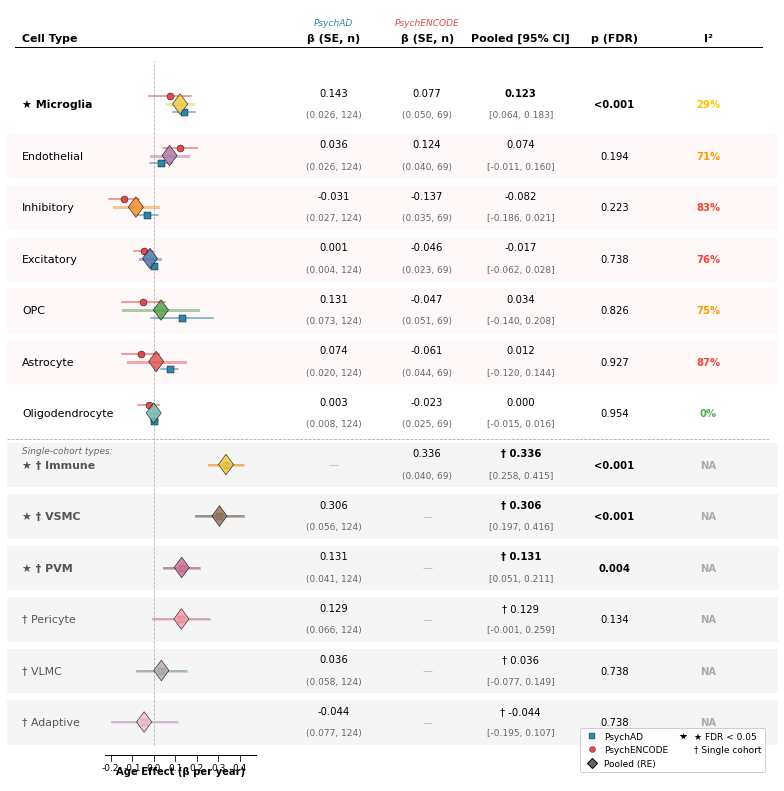


✓ Saved: /fs/scratch/PAS2598/senescence_analysis/figures/03_meta_analysis/03a_lmm_coefficients/meta_lmm_forest_plot.pdf


In [9]:
print("\n" + "="*80)
print("FOREST PLOT: EQUAL SPACING VERSION")
print("="*80)

print(f"\nCreating forest plot for {len(df_meta)} cell types...")

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════

cohort_list = list(cohorts_metadata.keys())
n_cohorts_total = len(cohort_list)
n_rows = len(df_meta)
n_multi = (df_meta['n_cohorts'] > 1).sum()

fig_width = 11
row_height = 0.7  # increased for larger fonts
fig_height = max(6, n_rows * row_height + 2)

fig = plt.figure(figsize=(fig_width, fig_height))
ax = fig.add_subplot(111)

# ═══════════════════════════════════════════════════════════════════════════════
# EQUAL COLUMN SPACING
# ═══════════════════════════════════════════════════════════════════════════════

x_pos = {
    'cell_type': 0.01,
    'forest_left': 0.12,
    'forest_right': 0.32,
}

# Equal spacing for data columns
n_data_cols = n_cohorts_total + 3  # cohorts + pooled + p + i2
data_start = 0.36
data_end = 0.98
col_spacing = (data_end - data_start) / n_data_cols

for i, dataset in enumerate(cohort_list):
    x_pos[dataset] = data_start + (i + 0.5) * col_spacing

x_pos['pooled'] = data_start + (n_cohorts_total + 0.5) * col_spacing
x_pos['pvalue'] = data_start + (n_cohorts_total + 1.5) * col_spacing
x_pos['i2'] = data_start + (n_cohorts_total + 2.5) * col_spacing

print(f"  Cohorts: {[cohorts_metadata[ds]['display_name'] for ds in cohort_list]}")
print(f"  Column spacing: {col_spacing:.3f}")

# ═══════════════════════════════════════════════════════════════════════════════
# LARGER FONTS
# ═══════════════════════════════════════════════════════════════════════════════

FONT_HEADER = 11
FONT_CELL = 11
FONT_DATA = 10
FONT_SMALL = 9
FONT_LEGEND = 9

# ═══════════════════════════════════════════════════════════════════════════════
# FOREST PLOT SCALING
# ═══════════════════════════════════════════════════════════════════════════════

all_vals = []
for _, row in df_meta.iterrows():
    all_vals.extend(row['cohort_betas'])
    all_vals.extend([row['RE_ci_lower'], row['RE_ci_upper']])

beta_min = min(all_vals) * 1.15
beta_max = max(all_vals) * 1.15

def beta_to_x(val):
    norm = (val - beta_min) / (beta_max - beta_min)
    return x_pos['forest_left'] + norm * (x_pos['forest_right'] - x_pos['forest_left'])

# ═══════════════════════════════════════════════════════════════════════════════
# HEADERS
# ═══════════════════════════════════════════════════════════════════════════════

y_cohort_labels = n_rows + 0.5
y_headers = n_rows + 0.18

# Cohort name labels
for dataset in cohort_list:
    display_name = cohorts_metadata[dataset]['display_name']
    color = COHORT_COLORS.get(display_name, '#808080')
    ax.text(x_pos[dataset], y_cohort_labels, display_name, 
            fontsize=FONT_SMALL, style='italic', color=color, 
            ha='center', va='bottom')

# Column headers
ax.text(x_pos['cell_type'], y_headers, 'Cell Type', 
        fontsize=FONT_HEADER, fontweight='bold', ha='left', va='bottom')

for dataset in cohort_list:
    ax.text(x_pos[dataset], y_headers, 'β (SE, n)', 
            fontsize=FONT_HEADER, fontweight='bold', ha='center', va='bottom')

ax.text(x_pos['pooled'], y_headers, 'Pooled [95% CI]', 
        fontsize=FONT_HEADER, fontweight='bold', ha='center', va='bottom')

ax.text(x_pos['pvalue'], y_headers, 'p (FDR)', 
        fontsize=FONT_HEADER, fontweight='bold', ha='center', va='bottom')

ax.text(x_pos['i2'], y_headers, 'I²', 
        fontsize=FONT_HEADER, fontweight='bold', ha='center', va='bottom')

ax.plot([0, 0.99], [y_headers - 0.08, y_headers - 0.08], 'k-', lw=1, clip_on=False)

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT ROWS
# ═══════════════════════════════════════════════════════════════════════════════

for idx, (_, row) in enumerate(df_meta.iterrows()):
    y = n_rows - idx - 1
    
    cell_type = row['Cell_Type']
    is_single = row['n_cohorts'] == 1
    is_sig = row['RE_Significant']
    
    # Background
    if is_single:
        ax.axhspan(y - 0.42, y + 0.42, color='#f5f5f5', alpha=1, zorder=0)
    elif not np.isnan(row['I2']) and row['I2'] > 50:
        ax.axhspan(y - 0.42, y + 0.42, color='#fff8f8', alpha=1, zorder=0)
    
    # Cell type name
    prefix = ""
    if is_sig:
        prefix += "★ "
    if is_single:
        prefix += "† "
    
    ax.text(x_pos['cell_type'], y, prefix + cell_type, 
            fontsize=FONT_CELL, 
            fontweight='bold' if is_sig else 'normal',
            color='#555' if is_single else 'black', 
            ha='left', va='center')
    
    # Forest plot points
    cell_color = CELL_TYPE_COLORS.get(cell_type, '#808080')
    cohorts = row['cohorts']
    datasets = row['datasets']
    betas = row['cohort_betas']
    ses = row['cohort_ses']
    
    offsets = [0] if len(cohorts) == 1 else [-0.15, 0.15]
    markers = ['s', 'o', '^', 'D']
    
    for i, (cohort, dataset, beta, se, y_off) in enumerate(zip(cohorts, datasets, betas, ses, offsets)):
        ci_l, ci_h = beta - 1.96 * se, beta + 1.96 * se
        x_l, x_h, x_b = beta_to_x(ci_l), beta_to_x(ci_h), beta_to_x(beta)
        
        c_color = COHORT_COLORS.get(cohort, '#808080')
        cohort_idx = next((j for j, ds in enumerate(cohort_list) 
                          if cohorts_metadata[ds]['display_name'] == cohort), 0)
        marker = markers[cohort_idx % len(markers)]
        
        ax.plot([x_l, x_h], [y + y_off, y + y_off], color=c_color, lw=1.5, alpha=0.7, zorder=2)
        ax.plot(x_b, y + y_off, marker, ms=7, color=c_color, mec='black', mew=0.4, zorder=3)
    
    # Pooled diamond
    re_b, re_l, re_h = row['RE_beta'], row['RE_ci_lower'], row['RE_ci_upper']
    x_re, x_re_l, x_re_h = beta_to_x(re_b), beta_to_x(re_l), beta_to_x(re_h)
    
    ax.plot([x_re_l, x_re_h], [y, y], color=cell_color, lw=3, alpha=0.5, zorder=4)
    
    from matplotlib.patches import Polygon
    dw, dh = 0.01, 0.2
    diamond = Polygon([[x_re-dw, y], [x_re, y-dh], [x_re+dw, y], [x_re, y+dh]], 
                      fc=cell_color, ec='black', lw=0.6, zorder=5, alpha=0.85)
    ax.add_patch(diamond)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Data columns - wrapped text
    # ─────────────────────────────────────────────────────────────────────────
    
    for dataset in cohort_list:
        display_name = cohorts_metadata[dataset]['display_name']
        cohort_idx = [i for i, c in enumerate(cohorts) if display_name in c]
        
        if cohort_idx:
            i = cohort_idx[0]
            n_donors = cohorts_metadata[dataset]['n_donors']
            # Stacked: β on top, (SE, n) below
            ax.text(x_pos[dataset], y + 0.12, f"{betas[i]:.3f}", 
                    fontsize=FONT_DATA, ha='center', va='bottom')
            ax.text(x_pos[dataset], y - 0.12, f"({ses[i]:.3f}, {n_donors})", 
                    fontsize=FONT_SMALL, ha='center', va='top', color='#666')
        else:
            ax.text(x_pos[dataset], y, '—', fontsize=FONT_DATA, ha='center', va='center', color='#bbb')
    
    # Pooled - stacked
    prefix = "† " if is_single else ""
    ax.text(x_pos['pooled'], y + 0.12, f"{prefix}{re_b:.3f}", 
            fontsize=FONT_DATA, ha='center', va='bottom',
            fontweight='bold' if is_sig else 'normal')
    ax.text(x_pos['pooled'], y - 0.12, f"[{re_l:.3f}, {re_h:.3f}]", 
            fontsize=FONT_SMALL, ha='center', va='top', color='#666')
    
    # P-value
    if row['RE_p_adj'] < 0.001:
        p_txt = '<0.001'
    else:
        p_txt = f"{row['RE_p_adj']:.3f}"
    ax.text(x_pos['pvalue'], y, p_txt, fontsize=FONT_DATA, ha='center', va='center',
            fontweight='bold' if is_sig else 'normal')
    
    # I²
    if is_single or np.isnan(row['I2']):
        i2_txt, i2_color = 'NA', '#aaa'
    else:
        i2 = row['I2']
        i2_txt = f"{i2:.0f}%"
        i2_color = '#4CAF50' if i2 < 25 else '#FFC107' if i2 < 50 else '#FF9800' if i2 < 75 else '#f44336'
    
    ax.text(x_pos['i2'], y, i2_txt, fontsize=FONT_DATA, ha='center', va='center', 
            color=i2_color, fontweight='bold')

# ═══════════════════════════════════════════════════════════════════════════════
# DIVIDER
# ═══════════════════════════════════════════════════════════════════════════════

if n_multi < n_rows:
    y_div = n_rows - n_multi - 0.5
    ax.axhline(y_div, color='#aaa', linestyle='--', lw=0.8, xmin=0, xmax=0.99)
    ax.text(x_pos['cell_type'], y_div - 0.15, 'Single-cohort types:', 
            fontsize=FONT_SMALL, color='#666', style='italic', ha='left', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# X-AXIS
# ═══════════════════════════════════════════════════════════════════════════════

y_axis = -0.65
ax.plot([x_pos['forest_left'], x_pos['forest_right']], [y_axis, y_axis], 'k-', lw=1)

x_zero = beta_to_x(0)
ax.axvline(x_zero, color='#888', linestyle='--', lw=0.8, ymin=0.05, ymax=0.93, alpha=0.6)

ax.text((x_pos['forest_left'] + x_pos['forest_right']) / 2, y_axis - 0.35,
        'Age Effect (β per year)', fontsize=FONT_DATA, fontweight='bold', ha='center')

for tick in np.arange(-0.2, 0.5, 0.1):
    if beta_min <= tick <= beta_max:
        x_tick = beta_to_x(tick)
        ax.plot([x_tick, x_tick], [y_axis, y_axis - 0.1], 'k-', lw=0.8)
        ax.text(x_tick, y_axis - 0.15, f'{tick:.1f}', fontsize=FONT_SMALL, ha='center', va='top')

# ═══════════════════════════════════════════════════════════════════════════════
# LEGEND
# ═══════════════════════════════════════════════════════════════════════════════

from matplotlib.lines import Line2D

legend_elements = []
markers = ['s', 'o', '^', 'D']

for i, dataset in enumerate(cohort_list):
    display_name = cohorts_metadata[dataset]['display_name']
    color = COHORT_COLORS.get(display_name, '#808080')
    legend_elements.append(Line2D([0], [0], marker=markers[i], color='w', 
                                   markerfacecolor=color, markersize=6, 
                                   markeredgecolor='black', markeredgewidth=0.3,
                                   label=display_name))

legend_elements.append(Line2D([0], [0], marker='D', color='w', markerfacecolor='#666', 
                               markersize=7, markeredgecolor='black', label='Pooled (RE)'))
legend_elements.append(Line2D([0], [0], marker='*', color='w', markerfacecolor='black', 
                               markersize=10, label='★ FDR < 0.05'))
legend_elements.append(Line2D([0], [0], marker='', color='w', label='† Single cohort'))

ax.legend(handles=legend_elements, loc='lower right', fontsize=FONT_LEGEND, 
          frameon=True, framealpha=0.95, edgecolor='#ccc', ncol=2,
          bbox_to_anchor=(0.99, 0.01), handletextpad=0.3, columnspacing=0.6)

# ═══════════════════════════════════════════════════════════════════════════════
# FINAL
# ═══════════════════════════════════════════════════════════════════════════════

ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-1.2, n_rows + 0.9)
ax.axis('off')

plt.tight_layout()

output_path = FIGURES_DIR / 'meta_lmm_forest_plot.pdf'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / 'meta_lmm_forest_plot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Saved: {output_path}")
print("="*80)


TRAJECTORY PLOT: PREVALENCE ACROSS STUDY GROUPS

  Loading donor × cell type data...
    ✓ PsychAD: 1,419 rows, 12 cell types
      ⚠ Dropped 69 rows with missing Study_Group
      Study groups: ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']
    ✓ PsychENCODE: 535 rows, 8 cell types
      ⚠ Dropped 17 rows with missing Study_Group
      Study groups: ['Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']

  Combined: 1,954 rows from 2 cohorts

  Calculating prevalence by study group...

  Calculating pooled estimates (meta-analysis)...
    ✓ Pooled estimates: 90 (Cell_Type × Study_Group)
  Study groups: ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-100']
  Cell types: 7


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

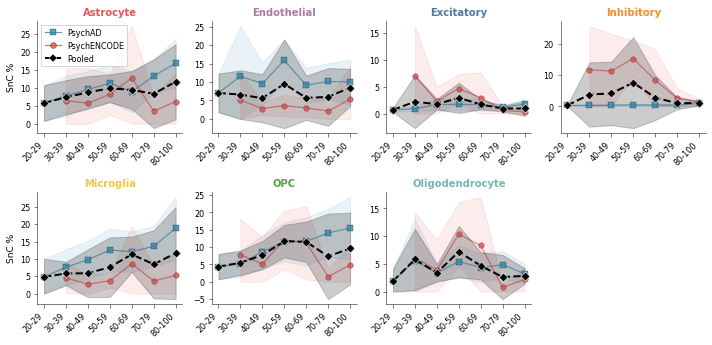


  ✓ Saved: trajectory_prevalence.pdf/.png


In [10]:
# ════════════════════════════════════════════════════════════════════════════════
# TRAJECTORY PLOT WITH POOLED ESTIMATES
# ════════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("TRAJECTORY PLOT: PREVALENCE ACROSS STUDY GROUPS")
print("="*70)

# ─────────────────────────────────────────────────────────────────────────────────
# CONFIGURATION (self-contained definitions)
# ─────────────────────────────────────────────────────────────────────────────────

# Input directory
RESULTS_DIR_INPUT = BASE_DIR / 'results' / '02.5_probability_modeling'

# Cell type harmonization map
CELLTYPE_MAP = {
    'OPCs': 'OPC',
    'Oligodendrocytes': 'Oligodendrocyte',
    'Astrocytes': 'Astrocyte',
    'Vascular': 'Endothelial',
}

# Cell type colors (reference existing or define)
CELLTYPE_COLORS = CELL_TYPE_COLORS if 'CELL_TYPE_COLORS' in dir() else {
    'Astrocyte': '#FF6B6B', 'Microglia': '#4ECDC4', 'OPC': '#45B7D1',
    'Oligodendrocyte': '#96CEB4', 'Excitatory': '#FFEAA7', 'Inhibitory': '#DDA0DD',
    'Endothelial': '#98D8C8', 'Pericyte': '#F7DC6F', 'VLMC': '#BB8FCE',
    'VSMC': '#85C1E9', 'Immune': '#F8B500', 'PVM': '#16A085',
    'Adaptive': '#E74C3C', 'Vascular': '#98D8C8',
}

# Cohort markers
COHORT_MARKERS = {
    'PsychAD': 's',
    'PsychENCODE': 'o',
    'ROSMAP': '^',
    'Mathys': 'D',
}

# Font sizes
FONT_TITLE = 10
FONT_AXIS_LABEL = 9
FONT_TICK = 8
FONT_LEGEND = 8

# ─────────────────────────────────────────────────────────────────────────────────
# Load donor × cell type data from each cohort
# ─────────────────────────────────────────────────────────────────────────────────

print("\n  Loading donor × cell type data...")

df_traj_list = []

for dataset, info in cohorts_metadata.items():
    donor_ct_file = RESULTS_DIR_INPUT / dataset / f"{dataset}_df_donor_ct.csv"
    
    if not donor_ct_file.exists():
        print(f"    ✗ {info['display_name']}: {donor_ct_file.name} not found")
        continue
    
    df = pd.read_csv(donor_ct_file)
    df['Cohort_Name'] = info['display_name']
    df['Dataset'] = dataset
    
    # Harmonize cell types
    df['Cell_Type'] = df['Cell_Type'].replace(CELLTYPE_MAP)
    
    # Drop rows with missing Study_Group
    n_before = len(df)
    df = df.dropna(subset=['Study_Group'])
    n_dropped = n_before - len(df)
    
    print(f"    ✓ {info['display_name']}: {len(df):,} rows, {df['Cell_Type'].nunique()} cell types")
    if n_dropped > 0:
        print(f"      ⚠ Dropped {n_dropped} rows with missing Study_Group")
    print(f"      Study groups: {sorted(df['Study_Group'].unique())}")
    
    df_traj_list.append(df)

if len(df_traj_list) == 0:
    print("\n  ⚠ No donor-level data found. Skipping trajectory plot.")
else:
    df_traj = pd.concat(df_traj_list, ignore_index=True)
    print(f"\n  Combined: {len(df_traj):,} rows from {len(df_traj_list)} cohorts")

    # ─────────────────────────────────────────────────────────────────────────────
    # Calculate mean prevalence per Study_Group × Cell_Type × Cohort
    # ─────────────────────────────────────────────────────────────────────────────
    
    print("\n  Calculating prevalence by study group...")
    
    df_prev = df_traj.groupby(['Cohort_Name', 'Cell_Type', 'Study_Group']).agg(
        mean_prev=('prop_snc', 'mean'),
        std_prev=('prop_snc', 'std'),
        n_donors=('Donor', 'nunique'),
    ).reset_index()
    
    # Calculate SEM and 95% CI
    df_prev['sem'] = df_prev['std_prev'] / np.sqrt(df_prev['n_donors'])
    df_prev['sem'] = df_prev['sem'].fillna(0)
    df_prev['ci_lower'] = (df_prev['mean_prev'] - 1.96 * df_prev['sem']).clip(lower=0)
    df_prev['ci_upper'] = df_prev['mean_prev'] + 1.96 * df_prev['sem']
    
    # Convert to percentage
    df_prev['mean_pct'] = df_prev['mean_prev'] * 100
    df_prev['ci_lower_pct'] = df_prev['ci_lower'] * 100
    df_prev['ci_upper_pct'] = df_prev['ci_upper'] * 100
    df_prev['sem_pct'] = df_prev['sem'] * 100
    
    # ─────────────────────────────────────────────────────────────────────────────
    # Calculate POOLED estimates at each Study_Group × Cell_Type
    # ─────────────────────────────────────────────────────────────────────────────
    
    print("\n  Calculating pooled estimates (meta-analysis)...")
    
    pooled_results = []
    
    for (cell_type, study_group), group_df in df_prev.groupby(['Cell_Type', 'Study_Group']):
        means = group_df['mean_pct'].values
        sems = group_df['sem_pct'].values
        
        # Handle zero SEM
        sems = np.where(sems == 0, 0.001, sems)
        
        n_cohorts = len(means)
        
        if n_cohorts == 1:
            pooled = {
                'beta': means[0],
                'se': sems[0],
                'ci_lower': group_df['ci_lower_pct'].values[0],
                'ci_upper': group_df['ci_upper_pct'].values[0],
            }
        else:
            pooled = random_effects_meta(means, sems)
        
        pooled_results.append({
            'Cell_Type': cell_type,
            'Study_Group': study_group,
            'pooled_mean_pct': pooled['beta'],
            'pooled_se_pct': pooled['se'],
            'pooled_ci_lower_pct': pooled['ci_lower'],
            'pooled_ci_upper_pct': pooled['ci_upper'],
            'n_cohorts': n_cohorts,
        })
    
    df_pooled = pd.DataFrame(pooled_results)
    print(f"    ✓ Pooled estimates: {len(df_pooled)} (Cell_Type × Study_Group)")
    
    # ─────────────────────────────────────────────────────────────────────────────
    # Order study groups
    # ─────────────────────────────────────────────────────────────────────────────
    
    def get_group_order(sg):
        if pd.isna(sg):
            return 999
        sg = str(sg)
        if 'Age_' in sg or sg.startswith('Age'):
            try:
                parts = sg.replace('Age_', '').replace('Age', '').split('_')
                return int(parts[0])
            except:
                return 500
        disease_order = {
            'control': 10, 'ctrl': 10, 'healthy': 10, 'normal': 10,
            'nci': 20, 'mci': 30, 'ad': 40, 'alzheimer': 40, 'dementia': 40,
        }
        sg_lower = sg.lower()
        for key, val in disease_order.items():
            if key in sg_lower:
                return val
        return 500
    
    all_groups = sorted(df_prev['Study_Group'].dropna().unique(), key=get_group_order)
    group_to_idx = {g: i for i, g in enumerate(all_groups)}
    
    df_prev['group_order'] = df_prev['Study_Group'].map(group_to_idx)
    df_pooled['group_order'] = df_pooled['Study_Group'].map(group_to_idx)
    
    def format_group_label(sg):
        if pd.isna(sg):
            return 'NA'
        sg = str(sg)
        if 'Age_' in sg:
            parts = sg.replace('Age_', '').split('_')
            if len(parts) >= 2:
                return f"{parts[0]}-{parts[1]}"
        return sg
    
    group_labels = [format_group_label(g) for g in all_groups]
    print(f"  Study groups: {group_labels}")
    
    # ─────────────────────────────────────────────────────────────────────────────
    # Select cell types to plot
    # ─────────────────────────────────────────────────────────────────────────────
    
    cell_types_per_cohort = df_prev.groupby('Cohort_Name')['Cell_Type'].apply(set)
    common_types = set.intersection(*cell_types_per_cohort.values)
    common_types = common_types - {'Overall', 'overall', 'Total', 'total'}
    cell_types_to_plot = sorted(common_types)
    
    print(f"  Cell types: {len(cell_types_to_plot)}")
    
    # ─────────────────────────────────────────────────────────────────────────────
    # Create trajectory plot
    # ─────────────────────────────────────────────────────────────────────────────
    
    n_types = len(cell_types_to_plot)
    n_cols = min(4, n_types)
    n_rows_plot = int(np.ceil(n_types / n_cols))
    
    # Subplot dimensions
    fig_width = min(10, n_cols * 2.5)
    fig_height = n_rows_plot * 2.2 + 0.5
    
    fig, axes = plt.subplots(n_rows_plot, n_cols, figsize=(fig_width, fig_height), sharey=False)
    if n_types == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    cohort_names = df_prev['Cohort_Name'].unique()
    markers = ['s', 'o', '^', 'D', 'v', 'p']
    
    for idx, cell_type in enumerate(cell_types_to_plot):
        ax = axes[idx]
        ct_data = df_prev[df_prev['Cell_Type'] == cell_type]
        ct_pooled = df_pooled[df_pooled['Cell_Type'] == cell_type].sort_values('group_order')
        cell_color = CELLTYPE_COLORS.get(cell_type, '#808080')
        
        # Plot individual cohorts
        for i, cohort_name in enumerate(cohort_names):
            cohort_data = ct_data[ct_data['Cohort_Name'] == cohort_name].sort_values('group_order')
            
            if len(cohort_data) == 0:
                continue
            
            x = cohort_data['group_order'].values
            y = cohort_data['mean_pct'].values
            ci_l = cohort_data['ci_lower_pct'].values
            ci_u = cohort_data['ci_upper_pct'].values
            
            color = COHORT_COLORS.get(cohort_name, '#808080')
            marker = COHORT_MARKERS.get(cohort_name, markers[i % len(markers)])
            
            # CI band (subtle)
            ax.fill_between(x, ci_l, ci_u, alpha=0.1, color=color)
            
            # Line and markers
            ax.plot(x, y, '-', color=color, lw=1.2, alpha=0.6)
            ax.scatter(x, y, c=color, s=30, marker=marker,
                      edgecolors='black', linewidths=0.3, zorder=3, alpha=0.8)
        
        # Plot POOLED estimate (black dashed line with gray CI)
        if len(ct_pooled) > 0:
            x_pooled = ct_pooled['group_order'].values
            y_pooled = ct_pooled['pooled_mean_pct'].values
            ci_l_pooled = ct_pooled['pooled_ci_lower_pct'].values
            ci_u_pooled = ct_pooled['pooled_ci_upper_pct'].values
            
            # Gray CI band for pooled
            ax.fill_between(x_pooled, ci_l_pooled, ci_u_pooled, 
                           alpha=0.2, color='black', zorder=2)
            
            # Black dashed line for pooled mean
            ax.plot(x_pooled, y_pooled, '--', color='black', lw=2, zorder=4)
            ax.scatter(x_pooled, y_pooled, c='black', s=40, marker='D',
                      edgecolors='white', linewidths=0.6, zorder=5)
        
        # Formatting
        ax.set_title(cell_type, fontsize=FONT_TITLE, fontweight='bold', color=cell_color)
        ax.set_xticks(range(len(all_groups)))
        ax.set_xticklabels(group_labels, rotation=45, ha='right', fontsize=FONT_TICK)
        ax.tick_params(axis='y', labelsize=FONT_TICK)
        if idx % n_cols == 0:
            ax.set_ylabel('SnC %', fontsize=FONT_AXIS_LABEL)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Hide empty subplots
    for idx in range(n_types, len(axes)):
        axes[idx].axis('off')
    
    # Legend
    from matplotlib.lines import Line2D
    legend_elements = []
    for cohort_name in cohort_names:
        color = COHORT_COLORS.get(cohort_name, '#808080')
        marker = COHORT_MARKERS.get(cohort_name, 'o')
        legend_elements.append(
            Line2D([0], [0], marker=marker, color=color, lw=1.2,
                   markerfacecolor=color, markersize=6, markeredgecolor='black',
                   markeredgewidth=0.3, alpha=0.8, label=cohort_name))
    
    # Pooled legend entry
    legend_elements.append(
        Line2D([0], [0], marker='D', color='black', lw=2, ls='--',
               markerfacecolor='black', markersize=6, markeredgecolor='white',
               markeredgewidth=0.4, label='Pooled'))
    
    # Place legend in top-left of first subplot
    axes[0].legend(handles=legend_elements, loc='upper left', fontsize=FONT_LEGEND,
                  frameon=True, fancybox=False, edgecolor='#ccc')
    
    plt.tight_layout()
    
    # Save
    plt.savefig(FIGURES_DIR / 'trajectory_prevalence.pdf', bbox_inches='tight', facecolor='white')
    plt.savefig(FIGURES_DIR / 'trajectory_prevalence.png', bbox_inches='tight', facecolor='white')
    plt.show()
    
    print(f"\n  ✓ Saved: trajectory_prevalence.pdf/.png")

print("="*70)

# Module 03B: Meta-Analysis - Prevalence Approach

**Purpose:**
Meta-analyze absolute senescence prevalence levels (%SnC) across age groups to determine actual burden of cellular senescence at different life stages.

**What this answers:**
- "What percentage of cells are senescent at each age?"
- "How does prevalence differ between young, middle-aged, and elderly donors?"
- "Are prevalence levels consistent across cohorts?"

**Approach:**
- Calculate mean %SnC per donor per cell type
- Stratify donors into age bins (configurable)
- Meta-analyze prevalence across cohorts for each cell type × age bin combination
- Use random-effects model (DerSimonian-Laird)
- Assess heterogeneity (I², Cochran's Q, τ²)

**Two Complementary Analyses:**  <!-- NEW PARAGRAPH -->
1. **Percentage-based (Primary)**: Average % senescent per donor (patient perspective)
2. **Count-based (Sensitivity)**: Aggregate counts weighted by precision (tissue perspective)

**Complementary to Module 03A:**
- **Module 03A (Rate):** "How fast does senescence increase?" (β per year)
- **Module 03B (Level):** "What is the actual senescence burden?" (% at each age)

**Input:**
- Processed anndata objects with senescence scores
- Donor metadata (age, sex, cohort)
- Cell type annotations

**Statistical Methods:**
- Sample-level aggregation (mean %SnC per donor)
- Age stratification (configurable bins)
- Random-effects meta-analysis (DerSimonian-Laird)
- Heterogeneity assessment (I², Cochran's Q, τ²)
- FDR correction (Benjamini-Hochberg)

**Outputs:**
- CSV: Prevalence estimates per cell type × age bin with heterogeneity
- Forest plots: Age-stratified prevalence across cohorts
- Line plots: Prevalence trajectories across age
- Concordance analysis: Comparison of percentage vs count-based approaches

**Biological Interpretation:**
- Reports actual senescence burden in cell populations
- Shows age-related accumulation patterns
- Identifies cell types with highest senescence load
- Clinically relevant (% senescent cells, not just rate of change)

**Note:**
This approach is more descriptive and less adjusted than Module 03A (no covariate adjustment within age bins), but provides intuitive prevalence estimates.

**Author:** Gerald Gaitos  
**Date:** January 2026

In [9]:
print("\n" + "="*80)
print("MODULE 03B: PREVALENCE META-ANALYSIS")
print("="*80)

# Create Module 03B specific directories
RESULTS_DIR_03B = BASE_DIR / 'results' / '03_meta_analysis' / '03b_prevalence'
FIGURES_DIR_03B = BASE_DIR / 'figures' / '03_meta_analysis' / '03b_prevalence'

RESULTS_DIR_03B.mkdir(parents=True, exist_ok=True)
FIGURES_DIR_03B.mkdir(parents=True, exist_ok=True)

print(f"Results: {RESULTS_DIR_03B}")
print(f"Figures: {FIGURES_DIR_03B}")
print("\nNote: Using cohort configuration from Module 03A")
print("="*80)


MODULE 03B: PREVALENCE META-ANALYSIS
Results: /fs/scratch/PAS2598/senescence_analysis/results/03_meta_analysis/03b_prevalence
Figures: /fs/scratch/PAS2598/senescence_analysis/figures/03_meta_analysis/03b_prevalence

Note: Using cohort configuration from Module 03A


## Age Bin Configuration

Define age groups for stratified prevalence analysis.

In [10]:
print("\n" + "="*80)
print("AGE BIN DETECTION - ALL COHORTS")
print("="*80)

import scanpy as sc

# Check ALL cohorts for consistency
age_bin_columns = {}
age_bins_by_cohort = {}

for cohort in COHORTS:
    dataset = cohort['dataset']
    display_name = cohort['display_name']
    
    print(f"\nChecking {display_name}...")
    
    adata = sc.read_h5ad(BASE_DIR / 'data' / 'processed' / f'{dataset}_senescence_scored.h5ad')
    
    # Auto-detect age bin column
    age_bin_col = None
    possible_names = ['Study_Group', 'study_group', 'age_group', 'Age_Group', 
                      'disease_group', 'Disease_Group', 'Diagnosis_Group']
    
    for col in adata.obs.columns:
        if col in possible_names:
            age_bin_col = col
            break
    
    if age_bin_col is None:
        print(f"  ⚠ Could not detect age bin column")
        continue
    
    print(f"  ✓ Found: '{age_bin_col}'")
    
    # Get unique bins
    bins = sorted(adata.obs[age_bin_col].dropna().unique())
    print(f"  Bins ({len(bins)}): {', '.join(bins)}")
    
    age_bin_columns[dataset] = age_bin_col
    age_bins_by_cohort[dataset] = bins
    
    del adata

# Check consistency
print(f"\n" + "="*80)
print("CONSISTENCY CHECK")
print("="*80)

unique_col_names = set(age_bin_columns.values())
if len(unique_col_names) == 1:
    AGE_BIN_COLUMN = list(unique_col_names)[0]
    print(f"✓ All cohorts use same column: '{AGE_BIN_COLUMN}'")
else:
    print(f"⚠ WARNING: Different column names found:")
    for dataset, col in age_bin_columns.items():
        print(f"  {dataset}: {col}")
    print("\nUsing first cohort's column name as default.")
    AGE_BIN_COLUMN = list(age_bin_columns.values())[0]

# Get union of all age bins
all_bins = set()
for bins in age_bins_by_cohort.values():
    all_bins.update(bins)

AGE_BINS_LIST = sorted(all_bins)

print(f"\nUnique age bins across all cohorts ({len(AGE_BINS_LIST)}):")
for bin_name in AGE_BINS_LIST:
    cohorts_with_bin = [name for name, bins in age_bins_by_cohort.items() if bin_name in bins]
    print(f"  {bin_name}: {', '.join(cohorts_with_bin)}")

# Summary
print(f"\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Age bin column: '{AGE_BIN_COLUMN}'")
print(f"Total age bins: {len(AGE_BINS_LIST)}")
print(f"Cohorts checked: {len(COHORTS)}")
print("="*80)


AGE BIN DETECTION - ALL COHORTS

Checking PsychAD...
  ✓ Found: 'Study_Group'
  Bins (7): Age_20_29, Age_30_39, Age_40_49, Age_50_59, Age_60_69, Age_70_79, Age_80_100

Checking PsychENCODE...
  ✓ Found: 'Study_Group'
  Bins (6): Age_30_39, Age_40_49, Age_50_59, Age_60_69, Age_70_79, Age_80_100

CONSISTENCY CHECK
✓ All cohorts use same column: 'Study_Group'

Unique age bins across all cohorts (7):
  Age_20_29: psychad_aging
  Age_30_39: psychad_aging, psychencode_sub
  Age_40_49: psychad_aging, psychencode_sub
  Age_50_59: psychad_aging, psychencode_sub
  Age_60_69: psychad_aging, psychencode_sub
  Age_70_79: psychad_aging, psychencode_sub
  Age_80_100: psychad_aging, psychencode_sub

SUMMARY
Age bin column: 'Study_Group'
Total age bins: 7
Cohorts checked: 2


In [11]:
print("\n" + "="*80)
print("GENERATING DONOR-LEVEL SUMMARIES")
print("="*80)

import scanpy as sc

# Column name mappings per dataset
COLUMN_MAPPING = {
    'psychad_aging': {
        'donor_id': 'Sample',
        'age': 'Age',
        'sex': 'Sex',
        'cell_type': 'subclass',
    },
    'psychad_ad': {
        'donor_id': 'Sample',
        'age': 'Age',
        'sex': 'Sex',
        'cell_type': 'subclass',
    },
    'psychencode': {
        'donor_id': 'sample_id',
        'age': 'Age_death',
        'sex': 'Biological_Sex',  # FIXED: was 'Sex'
        'cell_type': 'major_celltype',
    },
    'psychencode_sub': {
        'donor_id': 'sample_id',
        'age': 'Age_death',
        'sex': 'Biological_Sex',  # FIXED: was 'Sex'
        'cell_type': 'major_celltype',
    },
}

donor_summary_dir = BASE_DIR / 'results' / '03_meta_analysis' / 'donor_summaries'
donor_summary_dir.mkdir(parents=True, exist_ok=True)

for cohort in COHORTS:
    dataset = cohort['dataset']
    display_name = cohort['display_name']
    
    print(f"\nProcessing {display_name}...")
    
    # Get column mapping for this dataset
    if dataset not in COLUMN_MAPPING:
        print(f"  ⚠ No column mapping defined for {dataset}")
        continue
    
    col_map = COLUMN_MAPPING[dataset]
    
    # Load anndata
    adata_path = BASE_DIR / 'data' / 'processed' / f'{dataset}_senescence_scored.h5ad'
    
    if not adata_path.exists():
        print(f"  ⚠ File not found: {adata_path}")
        continue
    
    adata = sc.read_h5ad(adata_path)
    print(f"  Loaded: {adata.n_obs:,} cells")
    
    # Build list of required columns with dataset-specific names
    required_cols = [
        col_map['donor_id'],
        col_map['cell_type'],
        col_map['age'],
        col_map['sex'],
        'is_senescent',
        AGE_BIN_COLUMN,
    ]
    
    # Check all columns exist
    missing_cols = [col for col in required_cols if col not in adata.obs.columns]
    if missing_cols:
        print(f"  ⚠ Missing columns: {missing_cols}")
        print(f"    Available columns: {list(adata.obs.columns[:10])}...")
        continue
    
    print(f"  Column mapping:")
    print(f"    Donor ID: '{col_map['donor_id']}'")
    print(f"    Cell type: '{col_map['cell_type']}'")
    print(f"    Age: '{col_map['age']}'")
    print(f"    Sex: '{col_map['sex']}'")
    print(f"    Study group: '{AGE_BIN_COLUMN}'")
    
    # Extract per-cell data
    df_cells = adata.obs[required_cols].copy()
    df_cells['Dataset'] = dataset
    df_cells['Cohort'] = display_name
    
    # Standardize column names
    df_cells.rename(columns={
        col_map['donor_id']: 'donor_id',
        col_map['cell_type']: 'cell_type',
        col_map['age']: 'age',
        col_map['sex']: 'sex',
        AGE_BIN_COLUMN: 'study_group',
    }, inplace=True)
    
    # Remove rows with missing study_group
    df_cells = df_cells[df_cells['study_group'].notna()]
    
    # Aggregate by donor, cell type, AND study group
    donor_summary = df_cells.groupby(['donor_id', 'cell_type', 'study_group']).agg({
        'is_senescent': ['sum', 'count'],
        'age': 'first',
        'sex': 'first',
        'Dataset': 'first',
        'Cohort': 'first',
    }).reset_index()
    
    donor_summary.columns = ['donor_id', 'cell_type', 'study_group', 
                              'n_senescent', 'n_total', 
                              'age', 'sex', 'Dataset', 'Cohort']
    
    donor_summary['percent_senescent'] = (donor_summary['n_senescent'] / donor_summary['n_total']) * 100
    
    # Save
    output_file = donor_summary_dir / f'donor_summary_{dataset}.csv'
    donor_summary.to_csv(output_file, index=False)
    
    print(f"  ✓ Saved: {output_file}")
    print(f"    Donors: {donor_summary['donor_id'].nunique()}")
    print(f"    Cell types: {donor_summary['cell_type'].nunique()}")
    print(f"    Study groups: {donor_summary['study_group'].nunique()}")
    print(f"    Observations: {len(donor_summary):,}")
    
    del adata

print("\n" + "="*80)
print("DONOR SUMMARIES GENERATED")
print("="*80)
print(f"Files saved to: {donor_summary_dir}")
print(f"Study group column used: '{AGE_BIN_COLUMN}'")
print("\n⚠ YOU CAN NOW SKIP THIS CELL AND USE CELL 5b FOR FUTURE RUNS")
print("="*80)


GENERATING DONOR-LEVEL SUMMARIES

Processing PsychAD...
  Loaded: 544,780 cells
  Column mapping:
    Donor ID: 'Sample'
    Cell type: 'subclass'
    Age: 'Age'
    Sex: 'Sex'
    Study group: 'Study_Group'
  ✓ Saved: /fs/scratch/PAS2598/senescence_analysis/results/03_meta_analysis/donor_summaries/donor_summary_psychad_aging.csv
    Donors: 124
    Cell types: 12
    Study groups: 7
    Observations: 10,416

Processing PsychENCODE...
  Loaded: 502,233 cells
  Column mapping:
    Donor ID: 'sample_id'
    Cell type: 'major_celltype'
    Age: 'Age_death'
    Sex: 'Biological_Sex'
    Study group: 'Study_Group'
  ✓ Saved: /fs/scratch/PAS2598/senescence_analysis/results/03_meta_analysis/donor_summaries/donor_summary_psychencode_sub.csv
    Donors: 69
    Cell types: 8
    Study groups: 6
    Observations: 3,312

DONOR SUMMARIES GENERATED
Files saved to: /fs/scratch/PAS2598/senescence_analysis/results/03_meta_analysis/donor_summaries
Study group column used: 'Study_Group'

⚠ YOU CAN NOW S

In [12]:
print("\n" + "="*80)
print("LOADING DONOR SUMMARIES")
print("="*80)

donor_summary_dir = BASE_DIR / 'results' / '03_meta_analysis' / 'donor_summaries'

donor_data_list = []

for cohort in COHORTS:
    dataset = cohort['dataset']
    display_name = cohort['display_name']
    
    summary_file = donor_summary_dir / f'donor_summary_{dataset}.csv'
    
    if not summary_file.exists():
        print(f"⚠ {display_name}: File not found - {summary_file}")
        print("   Run Cell 5a first to generate donor summaries!")
        continue
    
    df = pd.read_csv(summary_file)
    donor_data_list.append(df)
    
    print(f"✓ {display_name}:")
    print(f"  {len(df):,} observations")
    print(f"  {df['donor_id'].nunique()} donors")
    print(f"  {df['cell_type'].nunique()} cell types")
    print(f"  {df['study_group'].nunique()} study groups")

# Combine all cohorts
df_donor_all = pd.concat(donor_data_list, ignore_index=True)

# Display study groups present
print(f"\n" + "-"*80)
print("Study groups in combined data:")
for study_group in sorted(df_donor_all['study_group'].unique()):
    n_donors = df_donor_all[df_donor_all['study_group'] == study_group]['donor_id'].nunique()
    cohorts_with_group = df_donor_all[df_donor_all['study_group'] == study_group]['Cohort'].dropna().unique()
    cohorts_str = ', '.join(str(c) for c in cohorts_with_group)
    print(f"  {study_group}: {n_donors} donors ({cohorts_str})")

print(f"\n" + "="*80)
print("DATA LOADED")
print("="*80)
print(f"Total unique donors: {df_donor_all['donor_id'].nunique()}")
print(f"Total observations: {len(df_donor_all):,}")
print(f"Cell types: {df_donor_all['cell_type'].nunique()}")
print(f"Study groups: {df_donor_all['study_group'].nunique()}")
print(f"Age range: {df_donor_all['age'].min():.0f} - {df_donor_all['age'].max():.0f}")
print("="*80)


LOADING DONOR SUMMARIES
✓ PsychAD:
  10,416 observations
  124 donors
  12 cell types
  7 study groups
✓ PsychENCODE:
  3,312 observations
  69 donors
  8 cell types
  6 study groups

--------------------------------------------------------------------------------
Study groups in combined data:
  Age_20_29: 124 donors (PsychAD)
  Age_30_39: 193 donors (PsychAD, PsychENCODE)
  Age_40_49: 193 donors (PsychAD, PsychENCODE)
  Age_50_59: 193 donors (PsychAD, PsychENCODE)
  Age_60_69: 193 donors (PsychAD, PsychENCODE)
  Age_70_79: 193 donors (PsychAD, PsychENCODE)
  Age_80_100: 193 donors (PsychAD, PsychENCODE)

DATA LOADED
Total unique donors: 193
Total observations: 13,728
Cell types: 16
Study groups: 7
Age range: 20 - 90


In [13]:
print("\n" + "="*80)
print("CELL TYPE HARMONIZATION & DATA CLEANING")
print("="*80)

# Standardize to PsychAD convention (capitalized, singular)
HARMONIZATION_MAP = {
    # Lowercase → Capitalized
    'astrocyte': 'Astrocyte',
    'astrocytes': 'Astrocyte',
    'endothelial': 'Endothelial',
    'excitatory': 'Excitatory',
    'inhibitory': 'Inhibitory',
    'microglia': 'Microglia',
    'opc': 'OPC',
    'opcs': 'OPC',
    'oligodendrocyte': 'Oligodendrocyte',
    'oligodendrocytes': 'Oligodendrocyte',
    
    # Additional mappings
    'pericyte': 'Pericyte',
    'pericytes': 'Pericyte',
    'immune': 'Immune',
    'adaptive': 'Adaptive',
    'pvm': 'PVM',
    'vlmc': 'VLMC',
    'vsmc': 'VSMC',
    
    # Already standardized (PsychAD) - keep as-is
    'Astrocyte': 'Astrocyte',
    'Endothelial': 'Endothelial',
    'Excitatory': 'Excitatory',
    'Inhibitory': 'Inhibitory',
    'Microglia': 'Microglia',
    'OPC': 'OPC',
    'Oligodendrocyte': 'Oligodendrocyte',
    'Pericyte': 'Pericyte',
    'PVM': 'PVM',
    'VLMC': 'VLMC',
    'VSMC': 'VSMC',
    'Adaptive': 'Adaptive',
    'Immune': 'Immune',
}

print("Before harmonization:")
print(f"  Total observations: {len(df_donor_all):,}")
print(f"  Unique cell types: {df_donor_all['cell_type'].nunique()}")
print(f"  Cell types by cohort:")
for cohort in df_donor_all['Cohort'].dropna().unique():
    types = sorted(df_donor_all[df_donor_all['Cohort'] == cohort]['cell_type'].unique())
    print(f"    {cohort}: {types}")

# Apply harmonization
df_donor_all['cell_type_original'] = df_donor_all['cell_type'].copy()
df_donor_all['cell_type'] = df_donor_all['cell_type'].map(HARMONIZATION_MAP)

# Check for unmapped
unmapped = df_donor_all[df_donor_all['cell_type'].isna()]
if len(unmapped) > 0:
    print(f"\n⚠ Warning: {len(unmapped)} rows with unmapped cell types:")
    print(f"  Unmapped: {unmapped['cell_type_original'].unique()}")
    df_donor_all = df_donor_all[df_donor_all['cell_type'].notna()]

print(f"\nAfter harmonization:")
print(f"  Unique cell types: {df_donor_all['cell_type'].nunique()}")
print(f"  Standardized cell types: {sorted(df_donor_all['cell_type'].unique())}")

# Data cleaning
print(f"\n" + "-"*80)
print("Data cleaning:")
n_before = len(df_donor_all)
print(f"  Before: {n_before:,} observations")
print(f"  Zero cells (n_total=0): {(df_donor_all['n_total'] == 0).sum()}")
print(f"  NaN percent_senescent: {df_donor_all['percent_senescent'].isna().sum()}")
print(f"  NaN Cohort: {df_donor_all['Cohort'].isna().sum()}")

# Remove problematic rows
df_donor_all = df_donor_all[df_donor_all['n_total'] > 0].copy()
df_donor_all = df_donor_all.dropna(subset=['percent_senescent', 'Cohort'])

n_after = len(df_donor_all)
print(f"  After: {n_after:,} observations")
print(f"  Removed: {n_before - n_after:,} observations ({(n_before - n_after)/n_before*100:.1f}%)")

print(f"\n" + "-"*80)
print("Final summary:")
print(f"  Unique donors: {df_donor_all['donor_id'].nunique()}")
print(f"  Cell types: {df_donor_all['cell_type'].nunique()}")
print(f"  Study groups: {df_donor_all['study_group'].nunique()}")

# Cell type counts per cohort
print(f"\nCell type counts per cohort:")
for cohort in sorted(df_donor_all['Cohort'].unique()):
    cohort_subset = df_donor_all[df_donor_all['Cohort'] == cohort]
    types = cohort_subset['cell_type'].nunique()
    obs = len(cohort_subset)
    print(f"  {cohort}: {types} cell types, {obs:,} observations")

print("\n" + "="*80)


CELL TYPE HARMONIZATION & DATA CLEANING
Before harmonization:
  Total observations: 13,728
  Unique cell types: 16
  Cell types by cohort:
    PsychAD: ['Adaptive', 'Astrocyte', 'Endothelial', 'Excitatory', 'Inhibitory', 'Microglia', 'OPC', 'Oligodendrocyte', 'PVM', 'Pericyte', 'VLMC', 'VSMC']
    PsychENCODE: ['Astrocyte', 'Excitatory', 'Immune', 'Inhibitory', 'Microglia', 'OPCs', 'Oligodendrocytes', 'Vascular']

⚠ Warning: 1242 rows with unmapped cell types:
  Unmapped: ['OPCs' 'Oligodendrocytes' 'Vascular']

After harmonization:
  Unique cell types: 13
  Standardized cell types: ['Adaptive', 'Astrocyte', 'Endothelial', 'Excitatory', 'Immune', 'Inhibitory', 'Microglia', 'OPC', 'Oligodendrocyte', 'PVM', 'Pericyte', 'VLMC', 'VSMC']

--------------------------------------------------------------------------------
Data cleaning:
  Before: 12,486 observations
  Zero cells (n_total=0): 10735
  NaN percent_senescent: 10735
  NaN Cohort: 10735
  After: 1,751 observations
  Removed: 10,735 o

## Meta-Analysis Functions

Statistical functions for prevalence meta-analysis (reused from Module 03A).

In [14]:
print("\n" + "="*80)
print("META-ANALYSIS FUNCTIONS")
print("="*80)

def fixed_effects_meta(means, ses):
    """Fixed-effects meta-analysis using inverse variance weighting"""
    weights = 1 / (ses ** 2)
    pooled_mean = np.sum(weights * means) / np.sum(weights)
    pooled_se = np.sqrt(1 / np.sum(weights))
    pooled_z = pooled_mean / pooled_se
    pooled_p = 2 * (1 - stats.norm.cdf(abs(pooled_z)))
    
    ci_lower = pooled_mean - 1.96 * pooled_se
    ci_upper = pooled_mean + 1.96 * pooled_se
    
    return {
        'mean': pooled_mean,
        'se': pooled_se,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'z': pooled_z,
        'p_value': pooled_p,
    }

def random_effects_meta(means, ses):
    """Random-effects meta-analysis using DerSimonian-Laird method"""
    # Fixed-effects first
    fe = fixed_effects_meta(means, ses)
    
    # Calculate Q statistic
    weights = 1 / (ses ** 2)
    Q = np.sum(weights * (means - fe['mean']) ** 2)
    
    # Calculate tau-squared (between-study variance)
    df = len(means) - 1
    C = np.sum(weights) - np.sum(weights ** 2) / np.sum(weights)
    tau2 = max(0, (Q - df) / C) if C > 0 else 0
    
    # Random-effects weights
    re_weights = 1 / (ses ** 2 + tau2)
    pooled_mean = np.sum(re_weights * means) / np.sum(re_weights)
    pooled_se = np.sqrt(1 / np.sum(re_weights))
    pooled_z = pooled_mean / pooled_se
    pooled_p = 2 * (1 - stats.norm.cdf(abs(pooled_z)))
    
    ci_lower = pooled_mean - 1.96 * pooled_se
    ci_upper = pooled_mean + 1.96 * pooled_se
    
    return {
        'mean': pooled_mean,
        'se': pooled_se,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'z': pooled_z,
        'p_value': pooled_p,
        'tau2': tau2,
    }

def calculate_heterogeneity(means, ses):
    """Calculate I², Q statistic, and tau²"""
    weights = 1 / (ses ** 2)
    fe_mean = np.sum(weights * means) / np.sum(weights)
    
    Q = np.sum(weights * (means - fe_mean) ** 2)
    df = len(means) - 1
    
    p_Q = 1 - stats.chi2.cdf(Q, df) if df > 0 else np.nan
    
    I2 = max(0, ((Q - df) / Q) * 100) if Q > 0 else 0
    
    C = np.sum(weights) - np.sum(weights ** 2) / np.sum(weights)
    tau2 = max(0, (Q - df) / C) if C > 0 else 0
    
    return {
        'Q': Q,
        'df': df,
        'p_Q': p_Q,
        'I2': I2,
        'tau2': tau2,
    }

print("✓ Functions defined:")
print("  - fixed_effects_meta()")
print("  - random_effects_meta()")
print("  - calculate_heterogeneity()")
print("="*80)


META-ANALYSIS FUNCTIONS
✓ Functions defined:
  - fixed_effects_meta()
  - random_effects_meta()
  - calculate_heterogeneity()


## Meta-Analysis: Prevalence by Cell Type × Study Group

For each combination of cell type and study group, meta-analyze senescence prevalence across cohorts.

In [15]:
print("\n" + "="*80)
print("PREVALENCE META-ANALYSIS")
print("="*80)

# Get all cell types and study groups
all_cell_types = sorted(df_donor_all['cell_type'].unique())
all_study_groups = sorted(df_donor_all['study_group'].unique())

print(f"Cell types: {len(all_cell_types)}")
print(f"Study groups: {len(all_study_groups)}")
print(f"Total combinations: {len(all_cell_types) * len(all_study_groups)}")

meta_results = []

for cell_type in all_cell_types:
    for study_group in all_study_groups:
        
        # Filter data
        subset = df_donor_all[
            (df_donor_all['cell_type'] == cell_type) &
            (df_donor_all['study_group'] == study_group)
        ]
        
        if len(subset) == 0:
            continue
        
        # Get cohort-level summaries
        cohort_data = []
        for cohort_name in subset['Cohort'].unique():
            cohort_subset = subset[subset['Cohort'] == cohort_name]
            
            # Calculate mean and SE
            mean_prev = cohort_subset['percent_senescent'].mean()
            se_prev = cohort_subset['percent_senescent'].sem()
            n_donors = len(cohort_subset)
            
            cohort_data.append({
                'cohort': cohort_name,
                'mean': mean_prev,
                'se': se_prev,
                'n': n_donors,
            })
        
        if len(cohort_data) == 0:
            continue
        
        # Extract arrays
        cohorts = [d['cohort'] for d in cohort_data]
        means = np.array([d['mean'] for d in cohort_data])
        ses = np.array([d['se'] for d in cohort_data])
        ns = [d['n'] for d in cohort_data]
        
        # Handle single cohort
        if len(cohorts) == 1:
            result = {
                'Cell_Type': cell_type,
                'Study_Group': study_group,
                'n_cohorts': 1,
                'single_cohort_only': True,
                
                'cohorts': cohorts,
                'cohort_means': means.tolist(),
                'cohort_ses': ses.tolist(),
                'cohort_ns': ns,
                
                'FE_mean': means[0],
                'FE_se': ses[0],
                'FE_ci_lower': means[0] - 1.96 * ses[0],
                'FE_ci_upper': means[0] + 1.96 * ses[0],
                'FE_p_value': np.nan,
                
                'RE_mean': means[0],
                'RE_se': ses[0],
                'RE_ci_lower': means[0] - 1.96 * ses[0],
                'RE_ci_upper': means[0] + 1.96 * ses[0],
                'RE_p_value': np.nan,
                'RE_tau2': 0.0,
                
                'Q': np.nan,
                'Q_df': np.nan,
                'Q_p_value': np.nan,
                'I2': np.nan,
                'tau2': np.nan,
            }
        else:
            # Multi-cohort meta-analysis
            fe = fixed_effects_meta(means, ses)
            re = random_effects_meta(means, ses)
            het = calculate_heterogeneity(means, ses)
            
            result = {
                'Cell_Type': cell_type,
                'Study_Group': study_group,
                'n_cohorts': len(cohorts),
                'single_cohort_only': False,
                
                'cohorts': cohorts,
                'cohort_means': means.tolist(),
                'cohort_ses': ses.tolist(),
                'cohort_ns': ns,
                
                'FE_mean': fe['mean'],
                'FE_se': fe['se'],
                'FE_ci_lower': fe['ci_lower'],
                'FE_ci_upper': fe['ci_upper'],
                'FE_p_value': fe['p_value'],
                
                'RE_mean': re['mean'],
                'RE_se': re['se'],
                'RE_ci_lower': re['ci_lower'],
                'RE_ci_upper': re['ci_upper'],
                'RE_p_value': re['p_value'],
                'RE_tau2': re['tau2'],
                
                'Q': het['Q'],
                'Q_df': het['df'],
                'Q_p_value': het['p_Q'],
                'I2': het['I2'],
                'tau2': het['tau2'],
            }
        
        meta_results.append(result)

# Create dataframe
df_prevalence_meta = pd.DataFrame(meta_results)

# FDR correction
from statsmodels.stats.multitest import multipletests

# Only correct non-NaN p-values
valid_p = df_prevalence_meta['RE_p_value'].notna()
if valid_p.sum() > 0:
    df_prevalence_meta.loc[valid_p, 'RE_p_adj'] = multipletests(
        df_prevalence_meta.loc[valid_p, 'RE_p_value'], 
        method='fdr_bh'
    )[1]
else:
    df_prevalence_meta['RE_p_adj'] = np.nan

df_prevalence_meta['RE_Significant'] = df_prevalence_meta['RE_p_adj'] < 0.05

# Save
output_file = RESULTS_DIR_03B / 'meta_prevalence_results.csv'
df_prevalence_meta.to_csv(output_file, index=False)

print(f"\n✓ Meta-analysis complete")
print(f"  Results saved: {output_file}")
print(f"  Total combinations analyzed: {len(df_prevalence_meta)}")
print(f"  Multi-cohort: {(~df_prevalence_meta['single_cohort_only']).sum()}")
print(f"  Single-cohort: {df_prevalence_meta['single_cohort_only'].sum()}")

# Summary by study group
print(f"\n" + "-"*80)
print("Results by study group:")
for sg in sorted(df_prevalence_meta['Study_Group'].unique()):
    sg_subset = df_prevalence_meta[df_prevalence_meta['Study_Group'] == sg]
    n_multi = (~sg_subset['single_cohort_only']).sum()
    n_single = sg_subset['single_cohort_only'].sum()
    print(f"  {sg}: {len(sg_subset)} cell types ({n_multi} multi-cohort, {n_single} single-cohort)")

print("\n" + "="*80)


PREVALENCE META-ANALYSIS
Cell types: 13
Study groups: 7
Total combinations: 91

✓ Meta-analysis complete
  Results saved: /fs/scratch/PAS2598/senescence_analysis/results/03_meta_analysis/03b_prevalence/meta_prevalence_results.csv
  Total combinations analyzed: 90
  Multi-cohort: 24
  Single-cohort: 66

--------------------------------------------------------------------------------
Results by study group:
  Age_20_29: 12 cell types (0 multi-cohort, 12 single-cohort)
  Age_30_39: 13 cell types (4 multi-cohort, 9 single-cohort)
  Age_40_49: 13 cell types (4 multi-cohort, 9 single-cohort)
  Age_50_59: 13 cell types (4 multi-cohort, 9 single-cohort)
  Age_60_69: 13 cell types (4 multi-cohort, 9 single-cohort)
  Age_70_79: 13 cell types (4 multi-cohort, 9 single-cohort)
  Age_80_100: 13 cell types (4 multi-cohort, 9 single-cohort)



## Preview Meta-Analysis Results

Quick look at the prevalence data before visualization.

In [16]:
print("\n" + "="*80)
print("META-ANALYSIS RESULTS PREVIEW")
print("="*80)

# Show top results sorted by mean prevalence
df_preview = df_prevalence_meta.sort_values('RE_mean', ascending=False)

print("\nTop 10 highest prevalence (Study Group × Cell Type):")
print("-" * 80)
for i, (_, row) in enumerate(df_preview.head(10).iterrows(), 1):
    i2_str = 'NA' if pd.isna(row['I2']) or row['n_cohorts'] == 1 else f"{row['I2']:.0f}%"
    cohort_info = f"[{row['n_cohorts']} cohort{'s' if row['n_cohorts'] > 1 else ''}]"
    print(f"{i}. {row['Study_Group']} - {row['Cell_Type']}: "
          f"{row['RE_mean']:.2f}% (95% CI: [{row['RE_ci_lower']:.2f}, {row['RE_ci_upper']:.2f}], "
          f"I²={i2_str}, {cohort_info})")

# Show one age bin as example
example_age = 'Age_60_69'
print(f"\n\nExample: {example_age} across all cell types:")
print("-" * 80)
age_subset = df_prevalence_meta[df_prevalence_meta['Study_Group'] == example_age].sort_values('RE_mean', ascending=False)

for _, row in age_subset.head(10).iterrows():
    sig_marker = '★' if row['RE_Significant'] else ' '
    i2_str = 'NA' if pd.isna(row['I2']) or row['n_cohorts'] == 1 else f"{row['I2']:3.0f}%"
    n_coh = row['n_cohorts']
    print(f"{sig_marker} {row['Cell_Type']:20s}: {row['RE_mean']:6.2f}% "
          f"[{row['RE_ci_lower']:6.2f}, {row['RE_ci_upper']:6.2f}], I²={i2_str:>5s} (n={n_coh})")

# Summary statistics
print(f"\n" + "-"*80)
print("Summary:")
print(f"  Total combinations: {len(df_prevalence_meta)}")
print(f"  Multi-cohort (n≥2): {(df_prevalence_meta['n_cohorts'] >= 2).sum()}")
print(f"  Single-cohort (n=1): {(df_prevalence_meta['n_cohorts'] == 1).sum()}")
print(f"  Significant (FDR<0.05): {df_prevalence_meta['RE_Significant'].sum()}")

# Show which cell types are multi-cohort
print(f"\nMulti-cohort cell types (present in both PsychAD and PsychENCODE):")
multi_cohort = df_prevalence_meta[df_prevalence_meta['n_cohorts'] >= 2]
multi_cell_types = sorted(multi_cohort['Cell_Type'].unique())
print(f"  {', '.join(multi_cell_types)}")

print(f"\nSingle-cohort cell types (PsychAD only):")
single_cohort = df_prevalence_meta[df_prevalence_meta['n_cohorts'] == 1]
single_cell_types = sorted(single_cohort['Cell_Type'].unique())
print(f"  {', '.join(single_cell_types)}")

print("\n" + "="*80)


META-ANALYSIS RESULTS PREVIEW

Top 10 highest prevalence (Study Group × Cell Type):
--------------------------------------------------------------------------------
1. Age_50_59 - VSMC: 25.51% (95% CI: [5.07, 45.94], I²=NA, [1 cohort])
2. Age_70_79 - Pericyte: 22.69% (95% CI: [10.09, 35.29], I²=NA, [1 cohort])
3. Age_50_59 - Pericyte: 18.13% (95% CI: [7.78, 28.48], I²=NA, [1 cohort])
4. Age_80_100 - Pericyte: 16.95% (95% CI: [6.40, 27.50], I²=NA, [1 cohort])
5. Age_50_59 - Endothelial: 16.03% (95% CI: [10.54, 21.53], I²=NA, [1 cohort])
6. Age_80_100 - OPC: 15.80% (95% CI: [6.76, 24.84], I²=NA, [1 cohort])
7. Age_80_100 - Adaptive: 15.10% (95% CI: [1.96, 28.24], I²=NA, [1 cohort])
8. Age_60_69 - PVM: 14.89% (95% CI: [8.27, 21.52], I²=NA, [1 cohort])
9. Age_60_69 - VSMC: 14.82% (95% CI: [2.21, 27.42], I²=NA, [1 cohort])
10. Age_70_79 - VSMC: 14.76% (95% CI: [0.77, 28.74], I²=NA, [1 cohort])


Example: Age_60_69 across all cell types:
-----------------------------------------------------

## Trajectory Plots: Prevalence Across Age

Visualize senescence prevalence trajectories for each cell type across age bins.


TRAJECTORY PLOT: PREVALENCE ACROSS AGE


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

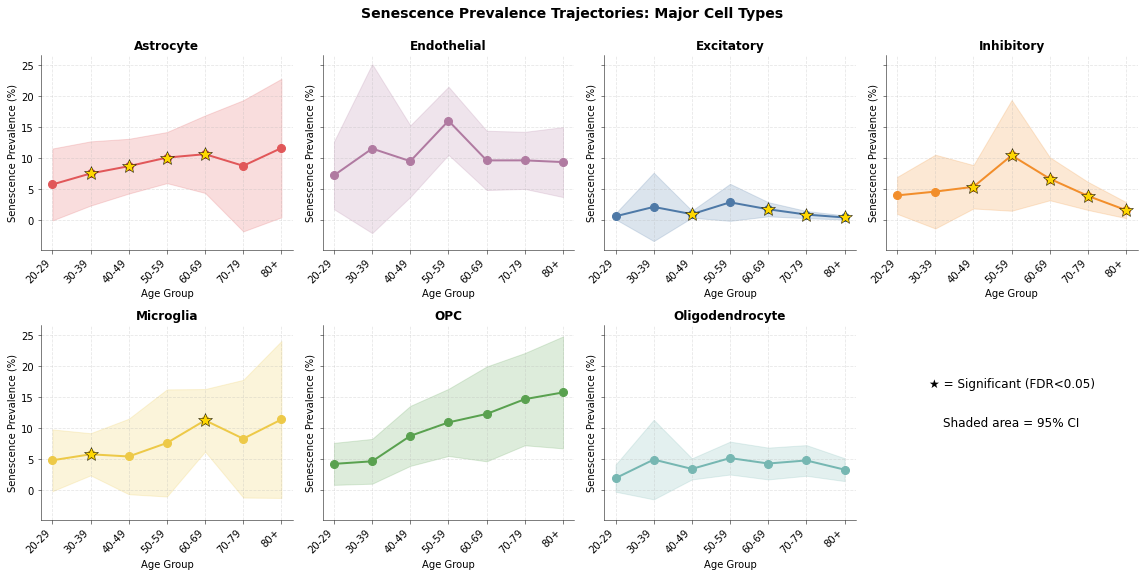


✓ Saved: /fs/scratch/PAS2598/senescence_analysis/figures/03_meta_analysis/03b_prevalence/prevalence_trajectories_major.pdf


In [17]:
print("\n" + "="*80)
print("TRAJECTORY PLOT: PREVALENCE ACROSS AGE")
print("="*80)

# Focus on multi-cohort cell types for cleaner plot
major_cell_types = ['Astrocyte', 'Endothelial', 'Excitatory', 'Inhibitory', 
                    'Microglia', 'OPC', 'Oligodendrocyte']

# Create figure
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.flatten()

# Age bin order and labels
age_order = ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 
             'Age_60_69', 'Age_70_79', 'Age_80_100']
age_labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']

for idx, cell_type in enumerate(major_cell_types):
    ax = axes[idx]
    
    # Get data for this cell type
    cell_data = df_prevalence_meta[df_prevalence_meta['Cell_Type'] == cell_type].copy()
    
    # Sort by age
    cell_data['age_order'] = cell_data['Study_Group'].map({ag: i for i, ag in enumerate(age_order)})
    cell_data = cell_data.sort_values('age_order')
    
    x = list(range(len(cell_data)))
    y = cell_data['RE_mean'].values
    ci_lower = cell_data['RE_ci_lower'].values
    ci_upper = cell_data['RE_ci_upper'].values
    is_sig = cell_data['RE_Significant'].values
    
    # Plot confidence intervals
    ax.fill_between(x, ci_lower, ci_upper, alpha=0.2, color=CELL_TYPE_COLORS.get(cell_type, '#808080'))
    
    # Plot line
    ax.plot(x, y, '-o', color=CELL_TYPE_COLORS.get(cell_type, '#808080'), 
            linewidth=2, markersize=8, label=cell_type)
    
    # Mark significant points
    for i, sig in enumerate(is_sig):
        if sig:
            ax.plot(x[i], y[i], '*', color='gold', markersize=15, 
                   markeredgecolor='black', markeredgewidth=0.5, zorder=5)
    
    # Formatting
    ax.set_title(cell_type, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([age_labels[i] for i in cell_data['age_order']], rotation=45, ha='right')
    ax.set_xlabel('Age Group', fontsize=10)
    ax.set_ylabel('Senescence Prevalence (%)', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Remove extra subplot
axes[-1].axis('off')

# Add legend to empty subplot
axes[-1].text(0.5, 0.7, '★ = Significant (FDR<0.05)', 
             ha='center', va='center', fontsize=12, transform=axes[-1].transAxes)
axes[-1].text(0.5, 0.5, 'Shaded area = 95% CI', 
             ha='center', va='center', fontsize=12, transform=axes[-1].transAxes)

plt.suptitle('Senescence Prevalence Trajectories: Major Cell Types', 
            fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig(FIGURES_DIR_03B / 'prevalence_trajectories_major.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {FIGURES_DIR_03B / 'prevalence_trajectories_major.pdf'}")
print("="*80)

## Forest Plots: Prevalence by Age Bin

Forest plots showing senescence prevalence across age bins for each cell type.

In [18]:
print("\n" + "="*80)
print("FOREST PLOT: PREVALENCE BY STUDY GROUP")
print("="*80)

def create_prevalence_forest_plot(cell_type_name, df_meta, output_path):
    """
    Create forest plot for one cell type showing prevalence across study groups
    Works for both aging cohorts (Age_20_29, etc.) and disease cohorts (Control, AD, etc.)
    """
    
    # Filter data for this cell type
    df_cell = df_meta[df_meta['Cell_Type'] == cell_type_name].copy()
    
    if len(df_cell) == 0:
        print(f"  ⚠ No data for {cell_type_name}")
        return
    
    # Auto-detect study groups and determine type
    study_groups = df_cell['Study_Group'].unique()
    
    # Detect if aging or disease cohort
    is_aging = any('Age_' in str(sg) for sg in study_groups)
    
    if is_aging:
        # Aging cohort: sort by age
        age_map = {}
        for sg in study_groups:
            if 'Age_' in str(sg):
                # Extract first number (e.g., Age_20_29 → 20, Age_80_100 → 80)
                num = int(str(sg).split('_')[1])
                age_map[sg] = num
        
        study_group_order = sorted(study_groups, key=lambda x: age_map.get(x, 999))
        
        # Create clean labels (Age_20_29 → 20-29)
        def clean_label(sg):
            parts = str(sg).replace('Age_', '').split('_')
            if len(parts) == 2:
                return f"{parts[0]}-{parts[1]}"
            elif len(parts) == 1:
                return parts[0]
            else:
                return str(sg).replace('Age_', '').replace('_', '-')
    else:
        # Disease cohort: Control first, then alphabetical
        control_groups = [sg for sg in study_groups if 'control' in str(sg).lower()]
        other_groups = sorted([sg for sg in study_groups if 'control' not in str(sg).lower()])
        study_group_order = control_groups + other_groups
        
        # Keep labels as-is for disease
        def clean_label(sg):
            return str(sg)
    
    # Sort dataframe
    df_cell['group_order'] = df_cell['Study_Group'].map({sg: i for i, sg in enumerate(study_group_order)})
    df_cell = df_cell.sort_values('group_order', ascending=False)  # Reverse for top-to-bottom
    
    n_rows = len(df_cell)
    
    # Create figure
    fig = plt.figure(figsize=(14, max(6, n_rows * 0.7)))
    ax = fig.add_subplot(111)
    
    # Column positions
    x_pos = {
        'group': 0.01,
        'forest_left': 0.14,
        'forest_right': 0.42,
        'cohort1': 0.48,
        'cohort2': 0.60,
        'pooled': 0.72,
        'pvalue': 0.85,
        'i2': 0.93,
    }
    
    # Font sizes
    FONT_XL = 13
    FONT_L = 12
    FONT_M = 11
    FONT_S = 10
    
    # Get prevalence range for x-axis
    all_vals = []
    for _, row in df_cell.iterrows():
        all_vals.extend(row['cohort_means'])
        all_vals.extend([row['RE_ci_lower'], row['RE_ci_upper']])
    
    prev_min = max(0, min(all_vals) - 5)
    prev_max = max(all_vals) + 5
    
    def prev_to_x(val):
        norm = (val - prev_min) / (prev_max - prev_min)
        return x_pos['forest_left'] + norm * (x_pos['forest_right'] - x_pos['forest_left'])
    
    # Headers
    y_cohort_labels = n_rows + 0.45
    y_headers = n_rows + 0.15
    
    # Get cohort names dynamically
    all_cohorts = []
    for _, row in df_cell.iterrows():
        all_cohorts.extend(row['cohorts'])
    unique_cohorts = sorted(set(all_cohorts))
    
    # Display cohort labels
    if len(unique_cohorts) >= 1:
        cohort1_name = unique_cohorts[0]
        cohort1_color = COHORT_COLORS.get(cohort1_name, '#1f77b4')
        ax.text(x_pos['cohort1'], y_cohort_labels, cohort1_name, 
                fontsize=FONT_S, style='italic', color=cohort1_color, 
                ha='center', va='bottom')
    
    if len(unique_cohorts) >= 2:
        cohort2_name = unique_cohorts[1]
        cohort2_color = COHORT_COLORS.get(cohort2_name, '#d62728')
        ax.text(x_pos['cohort2'], y_cohort_labels, cohort2_name, 
                fontsize=FONT_S, style='italic', color=cohort2_color, 
                ha='center', va='bottom')
    
    # Column headers
    group_label = 'Age Group' if is_aging else 'Group'
    
    ax.text(x_pos['group'], y_headers, group_label, 
            fontsize=FONT_L, fontweight='bold', ha='left', va='bottom')
    
    ax.text(x_pos['cohort1'], y_headers, '% (SE, n)', 
            fontsize=FONT_L, fontweight='bold', ha='center', va='bottom')
    
    ax.text(x_pos['cohort2'], y_headers, '% (SE, n)', 
            fontsize=FONT_L, fontweight='bold', ha='center', va='bottom')
    
    ax.text(x_pos['pooled'], y_headers, 'Pooled % [95% CI]', 
            fontsize=FONT_L, fontweight='bold', ha='center', va='bottom')
    
    ax.text(x_pos['pvalue'], y_headers, 'p', 
            fontsize=FONT_L, fontweight='bold', ha='center', va='bottom')
    
    ax.text(x_pos['i2'], y_headers, 'I²', 
            fontsize=FONT_L, fontweight='bold', ha='center', va='bottom')
    
    ax.plot([0, 0.98], [y_headers - 0.05, y_headers - 0.05], 'k-', lw=1.5, clip_on=False)
    
    # Plot rows
    for idx, (_, row) in enumerate(df_cell.iterrows()):
        y = n_rows - idx - 1
        
        study_group = row['Study_Group']
        group_label = clean_label(study_group)
        is_sig = row['RE_Significant']
        is_single = row['n_cohorts'] == 1
        
        # Background
        if is_single:
            ax.axhspan(y - 0.4, y + 0.4, color='#f8f8f8', alpha=1, zorder=0)
        
        # Group label
        label = f"★ {group_label}" if is_sig else group_label
        ax.text(x_pos['group'], y, label, 
                fontsize=FONT_XL, fontweight='bold' if is_sig else 'normal',
                color='black', ha='left', va='center')
        
        # Forest plot
        cell_color = CELL_TYPE_COLORS.get(cell_type_name, '#808080')
        cohorts = row['cohorts']
        means = row['cohort_means']
        ses = row['cohort_ses']
        
        offsets = [0] if len(cohorts) == 1 else [-0.15, 0.15]
        
        for c_idx, (cohort, mean, se, y_off) in enumerate(zip(cohorts, means, ses, offsets)):
            ci_l, ci_h = mean - 1.96 * se, mean + 1.96 * se
            x_l, x_h, x_m = prev_to_x(ci_l), prev_to_x(ci_h), prev_to_x(mean)
            
            c_color = COHORT_COLORS.get(cohort, '#808080')
            marker = 's' if c_idx == 0 else 'o'
            
            ax.plot([x_l, x_h], [y + y_off, y + y_off], color=c_color, lw=2, alpha=0.7, zorder=2)
            ax.plot(x_m, y + y_off, marker, ms=8, color=c_color, mec='black', mew=0.5, zorder=3)
        
        # Pooled estimate
        re_mean, re_l, re_h = row['RE_mean'], row['RE_ci_lower'], row['RE_ci_upper']
        x_re, x_re_l, x_re_h = prev_to_x(re_mean), prev_to_x(re_l), prev_to_x(re_h)
        
        ax.plot([x_re_l, x_re_h], [y, y], color=cell_color, lw=4, alpha=0.6, zorder=4)
        
        from matplotlib.patches import Polygon
        diamond = Polygon([[x_re - 0.015, y], [x_re, y - 0.25], 
                          [x_re + 0.015, y], [x_re, y + 0.25]], 
                          fc=cell_color, ec='black', lw=1.2, zorder=5, alpha=0.85)
        ax.add_patch(diamond)
        
        # Data columns
        if len(unique_cohorts) >= 1:
            cohort1_idx = [i for i, c in enumerate(cohorts) if c == unique_cohorts[0]]
            if cohort1_idx:
                i = cohort1_idx[0]
                n_donors = row['cohort_ns'][i]
                text = f"{means[i]:.1f} ({ses[i]:.1f}, {n_donors})"
                ax.text(x_pos['cohort1'], y, text, fontsize=FONT_M, ha='center', va='center')
            else:
                ax.text(x_pos['cohort1'], y, '—', fontsize=FONT_M, ha='center', va='center', color='#ccc')
        
        if len(unique_cohorts) >= 2:
            cohort2_idx = [i for i, c in enumerate(cohorts) if c == unique_cohorts[1]]
            if cohort2_idx:
                i = cohort2_idx[0]
                n_donors = row['cohort_ns'][i]
                text = f"{means[i]:.1f} ({ses[i]:.1f}, {n_donors})"
                ax.text(x_pos['cohort2'], y, text, fontsize=FONT_M, ha='center', va='center')
            else:
                ax.text(x_pos['cohort2'], y, '—', fontsize=FONT_M, ha='center', va='center', color='#ccc')
        
        # Pooled
        pooled_text = f"{re_mean:.1f} [{re_l:.1f}, {re_h:.1f}]"
        ax.text(x_pos['pooled'], y, pooled_text, fontsize=FONT_M, ha='center', va='center',
                fontweight='bold' if is_sig else 'normal')
        
        # p-value
        p_text = '<0.001' if row['RE_p_adj'] < 0.001 else f"{row['RE_p_adj']:.3f}"
        ax.text(x_pos['pvalue'], y, p_text, fontsize=FONT_M, ha='center', va='center',
                fontweight='bold' if is_sig else 'normal')
        
        # I²
        i2 = row['I2']
        if pd.isna(i2) or is_single:
            i2_text, i2_color = 'NA', '#999'
        else:
            i2_text = f"{i2:.0f}%"
            i2_color = '#2ca02c' if i2 < 25 else '#bcbd22' if i2 < 50 else '#ff7f0e' if i2 < 75 else '#d62728'
        
        ax.text(x_pos['i2'], y, i2_text, fontsize=FONT_M, ha='center', va='center',
                color=i2_color, fontweight='bold')
    
    # Axis
    y_axis = -0.4
    ax.plot([x_pos['forest_left'], x_pos['forest_right']], [y_axis, y_axis], 'k-', lw=1.5)
    
    ticks = np.linspace(prev_min, prev_max, 5)
    for t in ticks:
        xt = prev_to_x(t)
        ax.plot([xt, xt], [y_axis, y_axis - 0.08], 'k-', lw=1.2)
        ax.text(xt, y_axis - 0.13, f'{t:.0f}%', fontsize=FONT_S, ha='center', va='top')
    
    ax.text((x_pos['forest_left'] + x_pos['forest_right']) / 2, y_axis - 0.35,
            'Senescence Prevalence (%)', fontsize=FONT_L, fontweight='bold', 
            ha='center', va='top')
    
    # Legend
    legend_y = y_axis - 0.65
    legend_x_start = 0.56
    
    legend_specs = [
        ('■', COHORT_COLORS.get(unique_cohorts[0], '#1f77b4'), unique_cohorts[0] if len(unique_cohorts) >= 1 else 'Cohort 1', 0.00),
        ('●', COHORT_COLORS.get(unique_cohorts[1], '#d62728') if len(unique_cohorts) >= 2 else '#808080', 
         unique_cohorts[1] if len(unique_cohorts) >= 2 else 'Cohort 2', 0.075),
        ('◆', cell_color, 'Pooled', 0.18),
        ('★', 'black', 'Sig', 0.25),
    ]
    
    for symbol, color, label, x_offset in legend_specs:
        x_sym = legend_x_start + x_offset
        x_txt = x_sym + 0.015
        
        ax.text(x_sym, legend_y, symbol, fontsize=FONT_M, color=color, 
                fontweight='bold', ha='left', va='center')
        ax.text(x_txt, legend_y, label, fontsize=FONT_S, color='black',
                ha='left', va='center')
    
    # Title with proper spacing
    title_suffix = 'Across Age' if is_aging else 'Across Groups'
    fig.suptitle(f'{cell_type_name}: Senescence Prevalence {title_suffix}', 
                 fontsize=14, fontweight='bold', y=0.96)
    
    # Finalize
    ax.set_xlim(0, 0.98)
    ax.set_ylim(y_axis - 0.80, n_rows + 0.70)
    ax.axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"  ✓ {cell_type_name}")

print("✓ Generic forest plot function defined")
print("="*80)


FOREST PLOT: PREVALENCE BY STUDY GROUP
✓ Generic forest plot function defined


In [19]:
print("\n" + "="*80)
print("GENERATING FOREST PLOTS")
print("="*80)

# Major cell types
major_cell_types = ['Astrocyte', 'Endothelial', 'Excitatory', 'Inhibitory', 
                    'Microglia', 'OPC', 'Oligodendrocyte']

for cell_type in major_cell_types:
    output_file = FIGURES_DIR_03B / f'forest_plot_{cell_type.lower()}.pdf'
    create_prevalence_forest_plot(cell_type, df_prevalence_meta, output_file)

print(f"\n✓ All forest plots saved to: {FIGURES_DIR_03B}")
print("="*80)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


GENERATING FOREST PLOTS


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  ✓ Astrocyte


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

...

  ✓ Microglia


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  ✓ OPC


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  ✓ Oligodendrocyte

✓ All forest plots saved to: /fs/scratch/PAS2598/senescence_analysis/figures/03_meta_analysis/03b_prevalence


---

## Section 2: Sensitivity Analysis - Count-Based Meta-Analysis

**Rationale:**
The percentage-based approach (Section 1) treats all donors equally regardless of the number of cells sampled. The count-based approach weights observations by precision (donors with more cells contribute more information).

**Key Differences:**

| Aspect | Percentage-Based | Count-Based |
|--------|------------------|-------------|
| **Weights** | Each donor equally | By cell count (precision) |
| **Perspective** | Patient-level (typical donor) | Tissue-level (aggregate burden) |
| **Distribution** | Normal approximation | Binomial (proper) |
| **Transformation** | None | Freeman-Tukey arcsine |

**Statistical Method:**
- Freeman-Tukey double arcsine transformation for proportion meta-analysis
- Stabilizes variance across different prevalence levels
- Standard approach in clinical/epidemiological meta-analyses
- Back-transformed for interpretable reporting

**Expected Outcome:**
- If concordant with percentage-based → Results are robust
- If discordant → Investigate donor-level heterogeneity in cell counts

---

In [20]:
print("\n" + "="*80)
print("COUNT-BASED META-ANALYSIS FUNCTIONS")
print("="*80)

def freeman_tukey_transform(k, n):
    """
    Freeman-Tukey double arcsine transformation for proportions
    
    This transformation:
    - Stabilizes variance
    - Normalizes distribution
    - Handles 0 and 1 proportions
    
    Parameters:
    k: number of events (senescent cells)
    n: total observations (total cells)
    
    Returns:
    Transformed proportion
    """
    return np.arcsin(np.sqrt(k / (n + 1))) + np.arcsin(np.sqrt((k + 1) / (n + 1)))

def inverse_freeman_tukey(t, n):
    """
    Back-transform Freeman-Tukey to proportion
    
    Approximate inverse (exact inverse is complex)
    """
    # Approximate: use midpoint formula
    p = 0.5 * (1 - np.sign(np.cos(t)) * np.sqrt(1 - (np.sin(t) - (1 / np.sqrt(n)))**2))
    return np.clip(p, 0, 1) * 100  # Return as percentage

def count_based_meta_analysis(counts, totals):
    """
    Count-based meta-analysis using Freeman-Tukey transformation
    
    Parameters:
    counts: array of event counts (n_senescent per donor)
    totals: array of total counts (n_total per donor)
    
    Returns:
    dict with pooled estimate, CI, heterogeneity
    """
    
    n_studies = len(counts)
    
    if n_studies == 0:
        return None
    
    # Freeman-Tukey transformation
    transformed = np.array([freeman_tukey_transform(k, n) for k, n in zip(counts, totals)])
    
    # Variance of transformed proportions (approximately equal)
    variances = 1 / (totals + 0.5)
    weights = 1 / variances
    
    # Fixed-effects pooled estimate
    pooled_t = np.sum(weights * transformed) / np.sum(weights)
    se_t = np.sqrt(1 / np.sum(weights))
    
    # Calculate Q for heterogeneity
    Q = np.sum(weights * (transformed - pooled_t) ** 2)
    df = n_studies - 1
    p_Q = 1 - stats.chi2.cdf(Q, df) if df > 0 else np.nan
    
    # I²
    I2 = max(0, ((Q - df) / Q) * 100) if Q > 0 and df > 0 else 0
    
    # Tau² (between-study variance)
    C = np.sum(weights) - np.sum(weights ** 2) / np.sum(weights)
    tau2 = max(0, (Q - df) / C) if C > 0 and df > 0 else 0
    
    # Random-effects weights
    re_weights = 1 / (variances + tau2)
    pooled_t_re = np.sum(re_weights * transformed) / np.sum(re_weights)
    se_t_re = np.sqrt(1 / np.sum(re_weights))
    
    # Confidence intervals (in transformed space)
    ci_lower_t = pooled_t_re - 1.96 * se_t_re
    ci_upper_t = pooled_t_re + 1.96 * se_t_re
    
    # Back-transform to proportions (use average n for approximation)
    avg_n = np.mean(totals)
    pooled_p = inverse_freeman_tukey(pooled_t_re, avg_n)
    ci_lower = inverse_freeman_tukey(ci_lower_t, avg_n)
    ci_upper = inverse_freeman_tukey(ci_upper_t, avg_n)
    
    # P-value (test if different from 0)
    z = pooled_t_re / se_t_re
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    return {
        'mean': pooled_p,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'se': se_t_re,  # SE in transformed space
        'p_value': p_value,
        'Q': Q,
        'df': df,
        'p_Q': p_Q,
        'I2': I2,
        'tau2': tau2,
    }

def aggregate_donor_counts(df_donors, cell_type, study_group):
    """
    Aggregate counts by cohort for count-based meta-analysis
    
    Parameters:
    df_donors: donor-level dataframe
    cell_type: cell type to analyze
    study_group: study group to analyze
    
    Returns:
    dict with cohort-level aggregated counts
    """
    
    subset = df_donors[
        (df_donors['cell_type'] == cell_type) &
        (df_donors['study_group'] == study_group)
    ]
    
    if len(subset) == 0:
        return None
    
    cohort_data = []
    
    for cohort_name in subset['Cohort'].unique():
        cohort_subset = subset[subset['Cohort'] == cohort_name]
        
        # Sum counts across donors (aggregate to cohort level)
        total_senescent = cohort_subset['n_senescent'].sum()
        total_cells = cohort_subset['n_total'].sum()
        n_donors = len(cohort_subset)
        
        # Also calculate mean % for comparison
        mean_pct = cohort_subset['percent_senescent'].mean()
        se_pct = cohort_subset['percent_senescent'].sem()
        
        cohort_data.append({
            'cohort': cohort_name,
            'n_senescent': total_senescent,
            'n_total': total_cells,
            'n_donors': n_donors,
            'mean_pct': mean_pct,  # For comparison with percentage-based
            'se_pct': se_pct,
        })
    
    return cohort_data

print("✓ Count-based meta-analysis functions defined:")
print("  - freeman_tukey_transform()")
print("  - inverse_freeman_tukey()")
print("  - count_based_meta_analysis()")
print("  - aggregate_donor_counts()")
print("\nNote: Using Freeman-Tukey transformation for proper proportion meta-analysis")
print("="*80)


COUNT-BASED META-ANALYSIS FUNCTIONS
✓ Count-based meta-analysis functions defined:
  - freeman_tukey_transform()
  - inverse_freeman_tukey()
  - count_based_meta_analysis()
  - aggregate_donor_counts()

Note: Using Freeman-Tukey transformation for proper proportion meta-analysis


In [21]:
print("\n" + "="*80)
print("COUNT-BASED META-ANALYSIS EXECUTION")
print("="*80)

# Get all cell types and study groups
all_cell_types = sorted(df_donor_all['cell_type'].unique())
all_study_groups = sorted(df_donor_all['study_group'].unique())

print(f"Cell types: {len(all_cell_types)}")
print(f"Study groups: {len(all_study_groups)}")
print(f"Total combinations: {len(all_cell_types) * len(all_study_groups)}")

meta_results_count = []

for cell_type in all_cell_types:
    for study_group in all_study_groups:
        
        # Aggregate counts by cohort
        cohort_data = aggregate_donor_counts(df_donor_all, cell_type, study_group)
        
        if cohort_data is None or len(cohort_data) == 0:
            continue
        
        # Extract data
        cohorts = [d['cohort'] for d in cohort_data]
        counts = np.array([d['n_senescent'] for d in cohort_data])
        totals = np.array([d['n_total'] for d in cohort_data])
        n_donors = [d['n_donors'] for d in cohort_data]
        
        # For comparison with percentage-based
        pct_means = [d['mean_pct'] for d in cohort_data]
        pct_ses = [d['se_pct'] for d in cohort_data]
        
        # Handle single cohort
        if len(cohorts) == 1:
            # Simple proportion with binomial CI
            p = (counts[0] / totals[0]) * 100
            se = np.sqrt(p * (100 - p) / totals[0])
            ci_lower = max(0, p - 1.96 * se)
            ci_upper = min(100, p + 1.96 * se)
            
            result = {
                'Cell_Type': cell_type,
                'Study_Group': study_group,
                'n_cohorts': 1,
                'single_cohort_only': True,
                
                'cohorts': cohorts,
                'cohort_counts': counts.tolist(),
                'cohort_totals': totals.tolist(),
                'cohort_ns': n_donors,
                
                # Count-based estimates
                'CB_mean': p,
                'CB_ci_lower': ci_lower,
                'CB_ci_upper': ci_upper,
                'CB_p_value': np.nan,
                
                # For comparison with percentage-based
                'PB_mean': pct_means[0],
                'PB_se': pct_ses[0],
                
                'Q': np.nan,
                'Q_df': np.nan,
                'Q_p_value': np.nan,
                'I2': np.nan,
                'tau2': np.nan,
            }
        else:
            # Multi-cohort count-based meta-analysis
            meta_result = count_based_meta_analysis(counts, totals)
            
            if meta_result is None:
                continue
            
            result = {
                'Cell_Type': cell_type,
                'Study_Group': study_group,
                'n_cohorts': len(cohorts),
                'single_cohort_only': False,
                
                'cohorts': cohorts,
                'cohort_counts': counts.tolist(),
                'cohort_totals': totals.tolist(),
                'cohort_ns': n_donors,
                
                # Count-based estimates
                'CB_mean': meta_result['mean'],
                'CB_ci_lower': meta_result['ci_lower'],
                'CB_ci_upper': meta_result['ci_upper'],
                'CB_p_value': meta_result['p_value'],
                
                # For comparison with percentage-based
                'PB_mean': np.mean(pct_means),
                'PB_se': np.mean(pct_ses),
                
                'Q': meta_result['Q'],
                'Q_df': meta_result['df'],
                'Q_p_value': meta_result['p_Q'],
                'I2': meta_result['I2'],
                'tau2': meta_result['tau2'],
            }
        
        meta_results_count.append(result)

# Create dataframe
df_count_meta = pd.DataFrame(meta_results_count)

# FDR correction
from statsmodels.stats.multitest import multipletests

valid_p = df_count_meta['CB_p_value'].notna()
if valid_p.sum() > 0:
    df_count_meta.loc[valid_p, 'CB_p_adj'] = multipletests(
        df_count_meta.loc[valid_p, 'CB_p_value'], 
        method='fdr_bh'
    )[1]
else:
    df_count_meta['CB_p_adj'] = np.nan

df_count_meta['CB_Significant'] = df_count_meta['CB_p_adj'] < 0.05

# Save
output_file = RESULTS_DIR_03B / 'meta_prevalence_count_based.csv'
df_count_meta.to_csv(output_file, index=False)

print(f"\n✓ Count-based meta-analysis complete")
print(f"  Results saved: {output_file}")
print(f"  Total combinations analyzed: {len(df_count_meta)}")
print(f"  Multi-cohort: {(~df_count_meta['single_cohort_only']).sum()}")
print(f"  Single-cohort: {df_count_meta['single_cohort_only'].sum()}")

# Summary by study group
print(f"\n" + "-"*80)
print("Results by study group:")
for sg in sorted(df_count_meta['Study_Group'].unique()):
    sg_subset = df_count_meta[df_count_meta['Study_Group'] == sg]
    n_multi = (~sg_subset['single_cohort_only']).sum()
    n_single = sg_subset['single_cohort_only'].sum()
    print(f"  {sg}: {len(sg_subset)} cell types ({n_multi} multi-cohort, {n_single} single-cohort)")

print("\n" + "="*80)


COUNT-BASED META-ANALYSIS EXECUTION
Cell types: 13
Study groups: 7
Total combinations: 91

✓ Count-based meta-analysis complete
  Results saved: /fs/scratch/PAS2598/senescence_analysis/results/03_meta_analysis/03b_prevalence/meta_prevalence_count_based.csv
  Total combinations analyzed: 90
  Multi-cohort: 24
  Single-cohort: 66

--------------------------------------------------------------------------------
Results by study group:
  Age_20_29: 12 cell types (0 multi-cohort, 12 single-cohort)
  Age_30_39: 13 cell types (4 multi-cohort, 9 single-cohort)
  Age_40_49: 13 cell types (4 multi-cohort, 9 single-cohort)
  Age_50_59: 13 cell types (4 multi-cohort, 9 single-cohort)
  Age_60_69: 13 cell types (4 multi-cohort, 9 single-cohort)
  Age_70_79: 13 cell types (4 multi-cohort, 9 single-cohort)
  Age_80_100: 13 cell types (4 multi-cohort, 9 single-cohort)



In [22]:
print("\n" + "="*80)
print("COUNT-BASED META-ANALYSIS RESULTS PREVIEW")
print("="*80)

# Show top results sorted by mean prevalence
df_preview = df_count_meta.sort_values('CB_mean', ascending=False)

print("\nTop 10 highest prevalence (Study Group × Cell Type):")
print("-" * 80)
for i, (_, row) in enumerate(df_preview.head(10).iterrows(), 1):
    i2_str = 'NA' if pd.isna(row['I2']) or row['n_cohorts'] == 1 else f"{row['I2']:.0f}%"
    cohort_info = f"[{row['n_cohorts']} cohort{'s' if row['n_cohorts'] > 1 else ''}]"
    
    # Show total cells analyzed
    total_cells = sum(row['cohort_totals'])
    
    print(f"{i}. {row['Study_Group']} - {row['Cell_Type']}: "
          f"{row['CB_mean']:.2f}% (95% CI: [{row['CB_ci_lower']:.2f}, {row['CB_ci_upper']:.2f}], "
          f"I²={i2_str}, {cohort_info}, {total_cells:,} cells)")

# Show one age bin as example
example_age = 'Age_60_69'
print(f"\n\nExample: {example_age} across all cell types:")
print("-" * 80)
age_subset = df_count_meta[df_count_meta['Study_Group'] == example_age].sort_values('CB_mean', ascending=False)

for _, row in age_subset.head(10).iterrows():
    sig_marker = '★' if row['CB_Significant'] else ' '
    i2_str = 'NA' if pd.isna(row['I2']) or row['n_cohorts'] == 1 else f"{row['I2']:3.0f}%"
    n_coh = row['n_cohorts']
    total_cells = sum(row['cohort_totals'])
    
    print(f"{sig_marker} {row['Cell_Type']:20s}: {row['CB_mean']:6.2f}% "
          f"[{row['CB_ci_lower']:6.2f}, {row['CB_ci_upper']:6.2f}], "
          f"I²={i2_str:>5s} (n={n_coh}, {total_cells:,} cells)")

# Summary statistics
print(f"\n" + "-"*80)
print("Summary:")
print(f"  Total combinations: {len(df_count_meta)}")
print(f"  Multi-cohort (n≥2): {(df_count_meta['n_cohorts'] >= 2).sum()}")
print(f"  Single-cohort (n=1): {(df_count_meta['n_cohorts'] == 1).sum()}")
print(f"  Significant (FDR<0.05): {df_count_meta['CB_Significant'].sum()}")

print("\n" + "="*80)


COUNT-BASED META-ANALYSIS RESULTS PREVIEW

Top 10 highest prevalence (Study Group × Cell Type):
--------------------------------------------------------------------------------
1. Age_80_100 - Immune: 46.30% (95% CI: [41.99, 50.61], I²=NA, [1 cohort], 514 cells)
2. Age_60_69 - Immune: 18.45% (95% CI: [12.59, 24.32], I²=NA, [1 cohort], 168 cells)
3. Age_50_59 - Adaptive: 17.02% (95% CI: [9.42, 24.62], I²=NA, [1 cohort], 94 cells)
4. Age_60_69 - PVM: 16.67% (95% CI: [11.03, 22.30], I²=NA, [1 cohort], 168 cells)
5. Age_60_69 - Adaptive: 14.74% (95% CI: [9.18, 20.31], I²=NA, [1 cohort], 156 cells)
6. Age_80_100 - Microglia: 14.07% (95% CI: [12.80, 15.38], I²=26%, [2 cohorts], 3,948 cells)
7. Age_50_59 - Endothelial: 13.50% (95% CI: [11.33, 15.68], I²=NA, [1 cohort], 948 cells)
8. Age_50_59 - PVM: 13.19% (95% CI: [6.23, 20.14], I²=NA, [1 cohort], 91 cells)
9. Age_60_69 - OPC: 13.04% (95% CI: [12.04, 14.03], I²=NA, [1 cohort], 4,365 cells)
10. Age_80_100 - OPC: 13.00% (95% CI: [11.88, 14.12

### Forest Plots: Count-Based Prevalence

Forest plots showing count-based meta-analysis results for each cell type across study groups.

In [23]:
print("\n" + "="*80)
print("COUNT-BASED FOREST PLOT FUNCTION")
print("="*80)

def create_count_based_forest_plot(cell_type_name, df_meta, output_path):
    """
    Create forest plot for count-based meta-analysis
    Shows aggregated counts (n_senescent/n_total) per cohort
    """
    
    # Filter data for this cell type
    df_cell = df_meta[df_meta['Cell_Type'] == cell_type_name].copy()
    
    if len(df_cell) == 0:
        print(f"  ⚠ No data for {cell_type_name}")
        return
    
    # Auto-detect study groups and determine type
    study_groups = df_cell['Study_Group'].unique()
    is_aging = any('Age_' in str(sg) for sg in study_groups)
    
    if is_aging:
        # Aging cohort: sort by age
        age_map = {}
        for sg in study_groups:
            if 'Age_' in str(sg):
                num = int(str(sg).split('_')[1])
                age_map[sg] = num
        study_group_order = sorted(study_groups, key=lambda x: age_map.get(x, 999))
        
        def clean_label(sg):
            parts = str(sg).replace('Age_', '').split('_')
            if len(parts) == 2:
                return f"{parts[0]}-{parts[1]}"
            else:
                return str(sg).replace('Age_', '').replace('_', '-')
    else:
        # Disease cohort
        control_groups = [sg for sg in study_groups if 'control' in str(sg).lower()]
        other_groups = sorted([sg for sg in study_groups if 'control' not in str(sg).lower()])
        study_group_order = control_groups + other_groups
        
        def clean_label(sg):
            return str(sg)
    
    # Sort dataframe
    df_cell['group_order'] = df_cell['Study_Group'].map({sg: i for i, sg in enumerate(study_group_order)})
    df_cell = df_cell.sort_values('group_order', ascending=False)
    
    n_rows = len(df_cell)
    
    # Create figure
    fig = plt.figure(figsize=(14, max(6, n_rows * 0.8)))
    ax = fig.add_subplot(111)
    
    # Column positions - EQUAL SPACING
    group_width = 0.13
    forest_left = 0.14
    forest_width = 0.28
    forest_right = forest_left + forest_width
    
    # Calculate equal spacing for remaining columns
    remaining_width = 0.98 - forest_right
    n_gaps = 5  # cohort1, cohort2, pooled, pvalue, i2
    col_spacing = remaining_width / n_gaps
    
    x_pos = {
        'group': 0.01,
        'forest_left': forest_left,
        'forest_right': forest_right,
        'cohort1': forest_right + col_spacing * 0.5,
        'cohort2': forest_right + col_spacing * 1.5,
        'pooled': forest_right + col_spacing * 2.5,
        'pvalue': forest_right + col_spacing * 3.5,
        'i2': forest_right + col_spacing * 4.5,
    }
    
    # Font sizes
    FONT_XL = 13
    FONT_L = 12
    FONT_M = 11
    FONT_S = 10
    
    # Get prevalence range
    all_vals = []
    for _, row in df_cell.iterrows():
        # Calculate % from counts
        for cnt, tot in zip(row['cohort_counts'], row['cohort_totals']):
            if tot > 0:
                all_vals.append((cnt / tot) * 100)
        all_vals.extend([row['CB_ci_lower'], row['CB_ci_upper']])
    
    prev_min = max(0, min(all_vals) - 5)
    prev_max = max(all_vals) + 5
    
    def prev_to_x(val):
        norm = (val - prev_min) / (prev_max - prev_min)
        return x_pos['forest_left'] + norm * (x_pos['forest_right'] - x_pos['forest_left'])
    
    # Headers
    y_cohort_labels = n_rows + 0.50
    y_headers = n_rows + 0.15
    
    # Get cohort names
    all_cohorts = []
    for _, row in df_cell.iterrows():
        all_cohorts.extend(row['cohorts'])
    unique_cohorts = sorted(set(all_cohorts))
    
    # Display cohort labels
    if len(unique_cohorts) >= 1:
        cohort1_color = COHORT_COLORS.get(unique_cohorts[0], '#1f77b4')
        ax.text(x_pos['cohort1'], y_cohort_labels, unique_cohorts[0], 
                fontsize=FONT_S, style='italic', color=cohort1_color, 
                ha='center', va='bottom')
    
    if len(unique_cohorts) >= 2:
        cohort2_color = COHORT_COLORS.get(unique_cohorts[1], '#d62728')
        ax.text(x_pos['cohort2'], y_cohort_labels, unique_cohorts[1], 
                fontsize=FONT_S, style='italic', color=cohort2_color, 
                ha='center', va='bottom')
    
    # Column headers - MULTI-LINE TO PREVENT OVERLAP
    group_label = 'Age Group' if is_aging else 'Group'
    
    ax.text(x_pos['group'], y_headers + 0.1, group_label, 
            fontsize=FONT_L, fontweight='bold', ha='left', va='bottom')
    
    # Cohort 1 header (two lines)
    ax.text(x_pos['cohort1'], y_headers + 0.1, 'Sen/Total', 
            fontsize=FONT_L, fontweight='bold', ha='center', va='bottom')
    ax.text(x_pos['cohort1'], y_headers - 0.05, '(%, n)', 
            fontsize=FONT_S, ha='center', va='bottom')
    
    # Cohort 2 header (two lines)
    ax.text(x_pos['cohort2'], y_headers + 0.1, 'Sen/Total', 
            fontsize=FONT_L, fontweight='bold', ha='center', va='bottom')
    ax.text(x_pos['cohort2'], y_headers - 0.05, '(%, n)', 
            fontsize=FONT_S, ha='center', va='bottom')
    
    # Pooled header (two lines)
    ax.text(x_pos['pooled'], y_headers + 0.1, 'Pooled %', 
            fontsize=FONT_L, fontweight='bold', ha='center', va='bottom')
    ax.text(x_pos['pooled'], y_headers - 0.05, '[95% CI]', 
            fontsize=FONT_S, ha='center', va='bottom')
    
    ax.text(x_pos['pvalue'], y_headers + 0.1, 'p', 
            fontsize=FONT_L, fontweight='bold', ha='center', va='bottom')
    
    ax.text(x_pos['i2'], y_headers + 0.1, 'I²', 
            fontsize=FONT_L, fontweight='bold', ha='center', va='bottom')
    
    ax.plot([0, 0.98], [y_headers - 0.10, y_headers - 0.10], 'k-', lw=1.5, clip_on=False)
    
    # Plot rows
    for idx, (_, row) in enumerate(df_cell.iterrows()):
        y = n_rows - idx - 1
        
        study_group = row['Study_Group']
        group_label_text = clean_label(study_group)
        is_sig = row['CB_Significant']
        is_single = row['n_cohorts'] == 1
        
        # Background
        if is_single:
            ax.axhspan(y - 0.45, y + 0.45, color='#f8f8f8', alpha=1, zorder=0)
        
        # Group label
        label = f"★ {group_label_text}" if is_sig else group_label_text
        ax.text(x_pos['group'], y, label, 
                fontsize=FONT_XL, fontweight='bold' if is_sig else 'normal',
                color='black', ha='left', va='center')
        
        # Forest plot
        cell_color = CELL_TYPE_COLORS.get(cell_type_name, '#808080')
        cohorts = row['cohorts']
        counts = row['cohort_counts']
        totals = row['cohort_totals']
        
        offsets = [0] if len(cohorts) == 1 else [-0.15, 0.15]
        
        for c_idx, (cohort, cnt, tot, y_off) in enumerate(zip(cohorts, counts, totals, offsets)):
            if tot == 0:
                continue
            
            pct = (cnt / tot) * 100
            # Binomial CI
            se = np.sqrt(pct * (100 - pct) / tot)
            ci_l = max(0, pct - 1.96 * se)
            ci_h = min(100, pct + 1.96 * se)
            
            x_l, x_h, x_m = prev_to_x(ci_l), prev_to_x(ci_h), prev_to_x(pct)
            
            c_color = COHORT_COLORS.get(cohort, '#808080')
            marker = 's' if c_idx == 0 else 'o'
            
            ax.plot([x_l, x_h], [y + y_off, y + y_off], color=c_color, lw=2, alpha=0.7, zorder=2)
            ax.plot(x_m, y + y_off, marker, ms=8, color=c_color, mec='black', mew=0.5, zorder=3)
        
        # Pooled estimate
        cb_mean, cb_l, cb_h = row['CB_mean'], row['CB_ci_lower'], row['CB_ci_upper']
        
        # Clip at 0%
        cb_l = max(0, cb_l)
        cb_h = max(0, cb_h)
        
        x_cb, x_cb_l, x_cb_h = prev_to_x(cb_mean), prev_to_x(cb_l), prev_to_x(cb_h)
        
        ax.plot([x_cb_l, x_cb_h], [y, y], color=cell_color, lw=4, alpha=0.6, zorder=4)
        
        from matplotlib.patches import Polygon
        diamond = Polygon([[x_cb - 0.015, y], [x_cb, y - 0.25], 
                          [x_cb + 0.015, y], [x_cb, y + 0.25]], 
                          fc=cell_color, ec='black', lw=1.2, zorder=5, alpha=0.85)
        ax.add_patch(diamond)
        
        # Data columns - TWO LINES TO MATCH HEADERS
        if len(unique_cohorts) >= 1:
            cohort1_idx = [i for i, c in enumerate(cohorts) if c == unique_cohorts[0]]
            if cohort1_idx:
                i = cohort1_idx[0]
                cnt, tot = counts[i], totals[i]
                pct = (cnt / tot) * 100 if tot > 0 else 0
                n_donors = row['cohort_ns'][i]
                
                # Line 1: Sen/Total
                text_line1 = f"{cnt}/{tot}"
                ax.text(x_pos['cohort1'], y + 0.15, text_line1, 
                       fontsize=FONT_M, ha='center', va='center')
                
                # Line 2: (%, n)
                text_line2 = f"({pct:.1f}%, {n_donors})"
                ax.text(x_pos['cohort1'], y - 0.15, text_line2, 
                       fontsize=FONT_S, ha='center', va='center', style='italic')
            else:
                ax.text(x_pos['cohort1'], y, '—', fontsize=FONT_M, ha='center', va='center', color='#ccc')
        
        if len(unique_cohorts) >= 2:
            cohort2_idx = [i for i, c in enumerate(cohorts) if c == unique_cohorts[1]]
            if cohort2_idx:
                i = cohort2_idx[0]
                cnt, tot = counts[i], totals[i]
                pct = (cnt / tot) * 100 if tot > 0 else 0
                n_donors = row['cohort_ns'][i]
                
                # Line 1: Sen/Total
                text_line1 = f"{cnt}/{tot}"
                ax.text(x_pos['cohort2'], y + 0.15, text_line1, 
                       fontsize=FONT_M, ha='center', va='center')
                
                # Line 2: (%, n)
                text_line2 = f"({pct:.1f}%, {n_donors})"
                ax.text(x_pos['cohort2'], y - 0.15, text_line2, 
                       fontsize=FONT_S, ha='center', va='center', style='italic')
            else:
                ax.text(x_pos['cohort2'], y, '—', fontsize=FONT_M, ha='center', va='center', color='#ccc')
        
        # Pooled (TWO LINES)
        # Line 1: Pooled %
        pooled_line1 = f"{cb_mean:.1f}%"
        ax.text(x_pos['pooled'], y + 0.15, pooled_line1, 
               fontsize=FONT_M, ha='center', va='center',
               fontweight='bold' if is_sig else 'normal')
        
        # Line 2: [95% CI]
        pooled_line2 = f"[{cb_l:.1f}, {cb_h:.1f}]"
        ax.text(x_pos['pooled'], y - 0.15, pooled_line2, 
               fontsize=FONT_S, ha='center', va='center',
               fontweight='bold' if is_sig else 'normal', style='italic')
        
        # p-value (single line)
        p_val = row['CB_p_adj']
        if pd.isna(p_val):
            p_text = 'nan'
        elif p_val < 0.001:
            p_text = '<0.001'
        else:
            p_text = f"{p_val:.3f}"
        ax.text(x_pos['pvalue'], y, p_text, fontsize=FONT_M, ha='center', va='center',
                fontweight='bold' if is_sig else 'normal')
        
        # I² (single line)
        i2 = row['I2']
        if pd.isna(i2) or is_single:
            i2_text, i2_color = 'NA', '#999'
        else:
            i2_text = f"{i2:.0f}%"
            i2_color = '#2ca02c' if i2 < 25 else '#bcbd22' if i2 < 50 else '#ff7f0e' if i2 < 75 else '#d62728'
        
        ax.text(x_pos['i2'], y, i2_text, fontsize=FONT_M, ha='center', va='center',
                color=i2_color, fontweight='bold')
    
    # Axis
    y_axis = -0.5
    ax.plot([x_pos['forest_left'], x_pos['forest_right']], [y_axis, y_axis], 'k-', lw=1.5)
    
    ticks = np.linspace(prev_min, prev_max, 5)
    for t in ticks:
        xt = prev_to_x(t)
        ax.plot([xt, xt], [y_axis, y_axis - 0.08], 'k-', lw=1.2)
        ax.text(xt, y_axis - 0.13, f'{t:.0f}%', fontsize=FONT_S, ha='center', va='top')
    
    ax.text((x_pos['forest_left'] + x_pos['forest_right']) / 2, y_axis - 0.35,
            'Senescence Prevalence (%)', fontsize=FONT_L, fontweight='bold', 
            ha='center', va='top')
    
    # Legend
    legend_y = y_axis - 0.65
    legend_x_start = 0.56
    
    legend_specs = [
        ('■', COHORT_COLORS.get(unique_cohorts[0], '#1f77b4'), unique_cohorts[0] if len(unique_cohorts) >= 1 else 'Cohort 1', 0.00),
        ('●', COHORT_COLORS.get(unique_cohorts[1], '#d62728') if len(unique_cohorts) >= 2 else '#808080', 
         unique_cohorts[1] if len(unique_cohorts) >= 2 else 'Cohort 2', 0.075),
        ('◆', cell_color, 'Pooled', 0.18),
        ('★', 'black', 'Sig', 0.25),
    ]
    
    for symbol, color, label, x_offset in legend_specs:
        x_sym = legend_x_start + x_offset
        x_txt = x_sym + 0.015
        
        ax.text(x_sym, legend_y, symbol, fontsize=FONT_M, color=color, 
                fontweight='bold', ha='left', va='center')
        ax.text(x_txt, legend_y, label, fontsize=FONT_S, color='black',
                ha='left', va='center')
    
    # Title
    title_suffix = 'Across Age' if is_aging else 'Across Groups'
    fig.suptitle(f'{cell_type_name}: Count-Based Prevalence {title_suffix}', 
                 fontsize=14, fontweight='bold', y=0.96)
    
    # Finalize
    ax.set_xlim(0, 0.98)
    ax.set_ylim(y_axis - 0.80, n_rows + 0.75)
    ax.axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"  ✓ {cell_type_name}")

print("✓ Count-based forest plot function defined")
print("="*80)


COUNT-BASED FOREST PLOT FUNCTION
✓ Count-based forest plot function defined


In [24]:
print("\n" + "="*80)
print("GENERATING COUNT-BASED FOREST PLOTS")
print("="*80)

# Major cell types
major_cell_types = ['Astrocyte', 'Endothelial', 'Excitatory', 'Inhibitory', 
                    'Microglia', 'OPC', 'Oligodendrocyte']

for cell_type in major_cell_types:
    output_file = FIGURES_DIR_03B / f'forest_plot_count_{cell_type.lower()}.pdf'
    create_count_based_forest_plot(cell_type, df_count_meta, output_file)

print(f"\n✓ All count-based forest plots saved to: {FIGURES_DIR_03B}")
print("="*80)


GENERATING COUNT-BASED FOREST PLOTS


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  ✓ Astrocyte


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  ✓ Endothelial


...

  ✓ Microglia


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  ✓ OPC


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

  ✓ Oligodendrocyte

✓ All count-based forest plots saved to: /fs/scratch/PAS2598/senescence_analysis/figures/03_meta_analysis/03b_prevalence


---

## Section 3: Concordance Assessment

**Purpose:**
Compare percentage-based and count-based estimates to assess robustness and identify cases where weighting matters.

**Questions:**
1. How correlated are the two approaches?
2. Where do they agree? Where do they disagree?
3. What drives discordance (cell count variability, donor heterogeneity)?
4. Which estimate is more appropriate for different interpretations?

**Key Metrics:**
- Pearson correlation (overall concordance)
- Absolute difference (magnitude of discordance)
- Relative difference (proportional discordance)
- I² comparison (heterogeneity detection)

---

In [25]:
print("\n" + "="*80)
print("COMPARING PERCENTAGE-BASED VS COUNT-BASED ESTIMATES")
print("="*80)

# Merge the two result sets
df_comparison = df_prevalence_meta.merge(
    df_count_meta,
    on=['Cell_Type', 'Study_Group'],
    how='inner',
    suffixes=('_pct', '_cnt')
)

print(f"Total combinations for comparison: {len(df_comparison)}")

# Check column names (for debugging)
print(f"\nColumns in merged dataframe: {len(df_comparison.columns)}")

# Calculate difference metrics
df_comparison['mean_diff'] = df_comparison['CB_mean'] - df_comparison['RE_mean']
df_comparison['abs_diff'] = np.abs(df_comparison['mean_diff'])
df_comparison['rel_diff'] = (df_comparison['mean_diff'] / df_comparison['RE_mean']) * 100

# Calculate correlation
valid_data = df_comparison[['RE_mean', 'CB_mean']].dropna()
correlation = valid_data.corr().iloc[0, 1]
print(f"\nPearson correlation: r = {correlation:.4f}")

# Summary statistics
print(f"\n" + "-"*80)
print("Difference Statistics:")
print(f"  Mean absolute difference: {df_comparison['abs_diff'].mean():.2f} percentage points")
print(f"  Median absolute difference: {df_comparison['abs_diff'].median():.2f} percentage points")
print(f"  Max absolute difference: {df_comparison['abs_diff'].max():.2f} percentage points")
print(f"  Mean relative difference: {df_comparison['rel_diff'].mean():.2f}%")

# Count agreement on significance - check for correct column names
sig_col_pct = 'RE_Significant' if 'RE_Significant' in df_comparison.columns else 'RE_Significant_pct'
sig_col_cnt = 'CB_Significant' if 'CB_Significant' in df_comparison.columns else 'CB_Significant_cnt'

both_sig = (df_comparison[sig_col_pct]) & (df_comparison[sig_col_cnt])
only_pct_sig = (df_comparison[sig_col_pct]) & (~df_comparison[sig_col_cnt])
only_cnt_sig = (~df_comparison[sig_col_pct]) & (df_comparison[sig_col_cnt])
neither_sig = (~df_comparison[sig_col_pct]) & (~df_comparison[sig_col_cnt])

print(f"\n" + "-"*80)
print("Significance Agreement:")
print(f"  Both significant: {both_sig.sum()} ({both_sig.sum()/len(df_comparison)*100:.1f}%)")
print(f"  Only percentage-based significant: {only_pct_sig.sum()}")
print(f"  Only count-based significant: {only_cnt_sig.sum()}")
print(f"  Neither significant: {neither_sig.sum()} ({neither_sig.sum()/len(df_comparison)*100:.1f}%)")

# Identify largest discrepancies
print(f"\n" + "-"*80)
print("Top 10 largest discrepancies (|percentage - count|):")
print("-" * 80)
top_discrepancies = df_comparison.nlargest(10, 'abs_diff')

for _, row in top_discrepancies.iterrows():
    pct_est = row['RE_mean']
    cnt_est = row['CB_mean']
    diff = row['mean_diff']
    
    # Get total cells - check which column name exists
    if 'cohort_totals' in row:
        total_cells = sum(row['cohort_totals']) if isinstance(row['cohort_totals'], list) else 0
    elif 'cohort_totals_cnt' in row:
        total_cells = sum(row['cohort_totals_cnt']) if isinstance(row['cohort_totals_cnt'], list) else 0
    else:
        total_cells = 0
    
    print(f"{row['Study_Group']} - {row['Cell_Type']:20s}: "
          f"Pct={pct_est:6.2f}%, Cnt={cnt_est:6.2f}%, "
          f"Diff={diff:+6.2f}pp ({total_cells:,} cells)")

# Heterogeneity comparison
print(f"\n" + "-"*80)
print("Heterogeneity (I²) Comparison:")

# Get n_cohorts column
n_coh_col = 'n_cohorts' if 'n_cohorts' in df_comparison.columns else 'n_cohorts_pct'
multi_cohort = df_comparison[df_comparison[n_coh_col] >= 2]

# Get I2 columns
i2_pct_col = 'I2' if 'I2' in df_comparison.columns else 'I2_pct'
i2_cnt_col = 'I2_cnt'

i2_pct = multi_cohort[i2_pct_col].dropna()
i2_cnt = multi_cohort[i2_cnt_col].dropna()

print(f"  Multi-cohort combinations: {len(multi_cohort)}")
print(f"  Percentage-based I² mean: {i2_pct.mean():.1f}%")
print(f"  Count-based I² mean: {i2_cnt.mean():.1f}%")

# Only calculate correlation if we have valid data
if len(i2_pct) > 0 and len(i2_cnt) > 0:
    i2_corr = multi_cohort[[i2_pct_col, i2_cnt_col]].dropna().corr().iloc[0, 1]
    print(f"  Correlation of I² values: {i2_corr:.3f}")

# Save comparison
output_file = RESULTS_DIR_03B / 'meta_prevalence_comparison.csv'
df_comparison.to_csv(output_file, index=False)
print(f"\n✓ Comparison saved: {output_file}")

print("="*80)


COMPARING PERCENTAGE-BASED VS COUNT-BASED ESTIMATES
Total combinations for comparison: 90

Columns in merged dataframe: 45

Pearson correlation: r = 0.5671

--------------------------------------------------------------------------------
Difference Statistics:
  Mean absolute difference: 2.78 percentage points
  Median absolute difference: 1.90 percentage points
  Max absolute difference: 35.87 percentage points
  Mean relative difference: -3.24%

--------------------------------------------------------------------------------
Significance Agreement:
  Both significant: 15 (16.7%)
  Only percentage-based significant: 0
  Only count-based significant: 7
  Neither significant: 68 (75.6%)

--------------------------------------------------------------------------------
Top 10 largest discrepancies (|percentage - count|):
--------------------------------------------------------------------------------
Age_80_100 - Immune              : Pct= 10.43%, Cnt= 46.30%, Diff=+35.87pp (514 cells)
A

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


VISUALIZING PERCENTAGE VS COUNT-BASED ESTIMATES


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

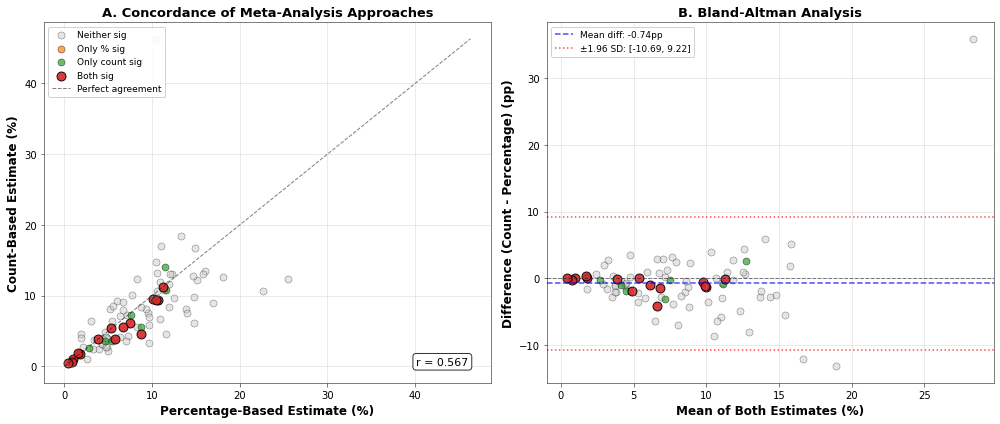


✓ Saved: /fs/scratch/PAS2598/senescence_analysis/figures/03_meta_analysis/03b_prevalence/prevalence_comparison_scatter.pdf


In [26]:
print("\n" + "="*80)
print("VISUALIZING PERCENTAGE VS COUNT-BASED ESTIMATES")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Get significance columns
sig_col_pct = 'RE_Significant' if 'RE_Significant' in df_comparison.columns else 'RE_Significant_pct'
sig_col_cnt = 'CB_Significant' if 'CB_Significant' in df_comparison.columns else 'CB_Significant_cnt'

# Panel A: Scatter plot of estimates
ax1 = axes[0]

# Color by agreement
both_sig = (df_comparison[sig_col_pct]) & (df_comparison[sig_col_cnt])
only_pct = (df_comparison[sig_col_pct]) & (~df_comparison[sig_col_cnt])
only_cnt = (~df_comparison[sig_col_pct]) & (df_comparison[sig_col_cnt])
neither = (~df_comparison[sig_col_pct]) & (~df_comparison[sig_col_cnt])

# Plot
ax1.scatter(df_comparison[neither]['RE_mean'], df_comparison[neither]['CB_mean'], 
           s=50, alpha=0.5, c='#cccccc', label='Neither sig', edgecolors='black', linewidths=0.5)
ax1.scatter(df_comparison[only_pct]['RE_mean'], df_comparison[only_pct]['CB_mean'], 
           s=50, alpha=0.7, c='#ff7f0e', label='Only % sig', edgecolors='black', linewidths=0.5)
ax1.scatter(df_comparison[only_cnt]['RE_mean'], df_comparison[only_cnt]['CB_mean'], 
           s=50, alpha=0.7, c='#2ca02c', label='Only count sig', edgecolors='black', linewidths=0.5)
ax1.scatter(df_comparison[both_sig]['RE_mean'], df_comparison[both_sig]['CB_mean'], 
           s=80, alpha=0.9, c='#d62728', label='Both sig', edgecolors='black', linewidths=1)

# Identity line
max_val = max(df_comparison['RE_mean'].max(), df_comparison['CB_mean'].max())
ax1.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=1, label='Perfect agreement')

# Formatting
ax1.set_xlabel('Percentage-Based Estimate (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count-Based Estimate (%)', fontsize=12, fontweight='bold')
ax1.set_title('A. Concordance of Meta-Analysis Approaches', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.text(0.95, 0.05, f'r = {correlation:.3f}', transform=ax1.transAxes, 
         fontsize=11, ha='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel B: Bland-Altman style plot (difference vs mean)
ax2 = axes[1]

mean_estimate = (df_comparison['RE_mean'] + df_comparison['CB_mean']) / 2
difference = df_comparison['mean_diff']

ax2.scatter(mean_estimate[neither], difference[neither], 
           s=50, alpha=0.5, c='#cccccc', edgecolors='black', linewidths=0.5)
ax2.scatter(mean_estimate[only_pct], difference[only_pct], 
           s=50, alpha=0.7, c='#ff7f0e', edgecolors='black', linewidths=0.5)
ax2.scatter(mean_estimate[only_cnt], difference[only_cnt], 
           s=50, alpha=0.7, c='#2ca02c', edgecolors='black', linewidths=0.5)
ax2.scatter(mean_estimate[both_sig], difference[both_sig], 
           s=80, alpha=0.9, c='#d62728', edgecolors='black', linewidths=1)

# Zero line
ax2.axhline(0, color='k', linestyle='--', alpha=0.5, linewidth=1)

# Mean difference and limits of agreement
mean_diff = difference.mean()
sd_diff = difference.std()
ax2.axhline(mean_diff, color='blue', linestyle='--', alpha=0.7, linewidth=1.5, 
           label=f'Mean diff: {mean_diff:.2f}pp')
ax2.axhline(mean_diff + 1.96*sd_diff, color='red', linestyle=':', alpha=0.7, linewidth=1.5,
           label=f'±1.96 SD: [{mean_diff-1.96*sd_diff:.2f}, {mean_diff+1.96*sd_diff:.2f}]')
ax2.axhline(mean_diff - 1.96*sd_diff, color='red', linestyle=':', alpha=0.7, linewidth=1.5)

# Formatting
ax2.set_xlabel('Mean of Both Estimates (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Difference (Count - Percentage) (pp)', fontsize=12, fontweight='bold')
ax2.set_title('B. Bland-Altman Analysis', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR_03B / 'prevalence_comparison_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {FIGURES_DIR_03B / 'prevalence_comparison_scatter.pdf'}")
print("="*80)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


CELL TYPE-SPECIFIC CONCORDANCE ANALYSIS


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

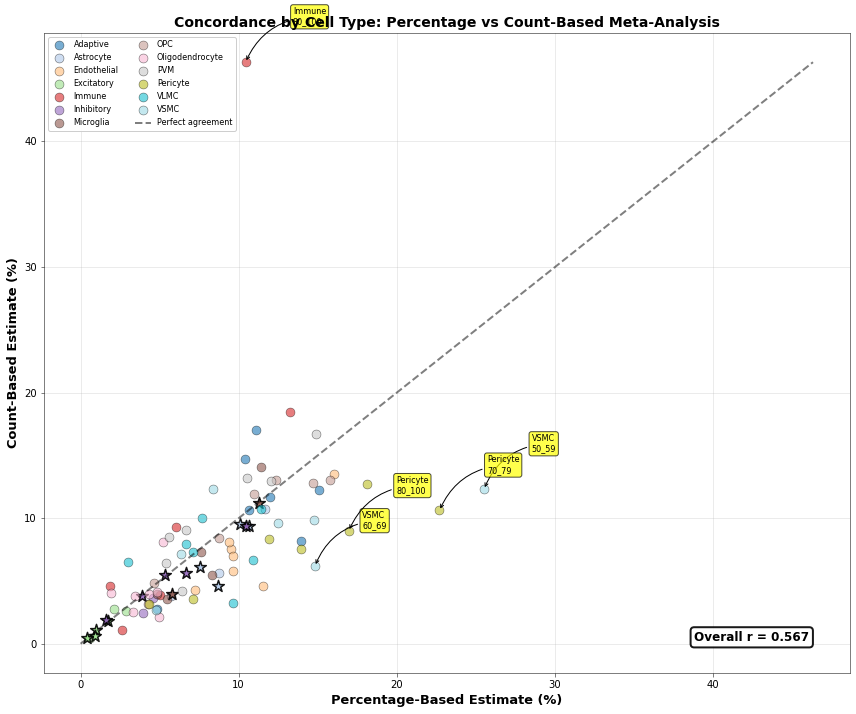


✓ Saved: /fs/scratch/PAS2598/senescence_analysis/figures/03_meta_analysis/03b_prevalence/prevalence_comparison_by_celltype.pdf

Note: Stars (*) indicate combinations significant in both approaches


In [27]:
print("\n" + "="*80)
print("CELL TYPE-SPECIFIC CONCORDANCE ANALYSIS")
print("="*80)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Get unique cell types
cell_types = sorted(df_comparison['Cell_Type'].unique())
n_types = len(cell_types)

# Generate colors for cell types
from matplotlib import cm
cell_type_colors_map = {}
cmap = cm.get_cmap('tab20', n_types)
for i, ct in enumerate(cell_types):
    cell_type_colors_map[ct] = cmap(i)

# Plot by cell type
for cell_type in cell_types:
    subset = df_comparison[df_comparison['Cell_Type'] == cell_type]
    
    # Separate by significance
    sig_col_pct = 'RE_Significant' if 'RE_Significant' in df_comparison.columns else 'RE_Significant_pct'
    sig_col_cnt = 'CB_Significant' if 'CB_Significant' in df_comparison.columns else 'CB_Significant_cnt'
    
    both_sig = (subset[sig_col_pct]) & (subset[sig_col_cnt])
    not_both = ~both_sig
    
    # Plot non-significant with smaller markers
    if not_both.sum() > 0:
        ax.scatter(subset[not_both]['RE_mean'], subset[not_both]['CB_mean'], 
                  s=80, alpha=0.6, c=[cell_type_colors_map[cell_type]], 
                  edgecolors='black', linewidths=0.5, label=cell_type)
    
    # Plot both significant with larger markers
    if both_sig.sum() > 0:
        ax.scatter(subset[both_sig]['RE_mean'], subset[both_sig]['CB_mean'], 
                  s=150, alpha=0.9, c=[cell_type_colors_map[cell_type]], 
                  edgecolors='black', linewidths=1.5, marker='*')

# Identity line
max_val = max(df_comparison['RE_mean'].max(), df_comparison['CB_mean'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=2, label='Perfect agreement')

# Annotate top 5 discrepancies
top_5_discrepancies = df_comparison.nlargest(5, 'abs_diff')
for _, row in top_5_discrepancies.iterrows():
    x, y = row['RE_mean'], row['CB_mean']
    label = f"{row['Cell_Type']}\n{row['Study_Group'].replace('Age_', '')}"
    
    # Add arrow pointing to point
    ax.annotate(label, xy=(x, y), xytext=(x+3, y+3),
               fontsize=8, ha='left',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', 
                             color='black', lw=1))

# Formatting
ax.set_xlabel('Percentage-Based Estimate (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count-Based Estimate (%)', fontsize=13, fontweight='bold')
ax.set_title('Concordance by Cell Type: Percentage vs Count-Based Meta-Analysis', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.text(0.95, 0.05, f'Overall r = {correlation:.3f}', transform=ax.transAxes, 
        fontsize=12, ha='right', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=2))

# Legend - split into two columns
handles, labels = ax.get_legend_handles_labels()
# Remove duplicates
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), 
         loc='upper left', fontsize=8, ncol=2, framealpha=0.95)

plt.tight_layout()
plt.savefig(FIGURES_DIR_03B / 'prevalence_comparison_by_celltype.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {FIGURES_DIR_03B / 'prevalence_comparison_by_celltype.pdf'}")
print("\nNote: Stars (*) indicate combinations significant in both approaches")
print("="*80)

In [28]:
print("\n" + "="*80)
print("CONCORDANCE METRICS BY CELL TYPE")
print("="*80)

# Calculate per-cell-type metrics
cell_type_summary = []

for cell_type in sorted(df_comparison['Cell_Type'].unique()):
    subset = df_comparison[df_comparison['Cell_Type'] == cell_type]
    
    # Basic stats
    n_combinations = len(subset)
    mean_abs_diff = subset['abs_diff'].mean()
    median_abs_diff = subset['abs_diff'].median()
    max_abs_diff = subset['abs_diff'].max()
    
    # Correlation (if enough points)
    if n_combinations >= 3:
        corr = subset[['RE_mean', 'CB_mean']].corr().iloc[0, 1]
    else:
        corr = np.nan
    
    # Significance agreement
    sig_col_pct = 'RE_Significant' if 'RE_Significant' in df_comparison.columns else 'RE_Significant_pct'
    sig_col_cnt = 'CB_Significant' if 'CB_Significant' in df_comparison.columns else 'CB_Significant_cnt'
    
    both_sig = ((subset[sig_col_pct]) & (subset[sig_col_cnt])).sum()
    only_pct = ((subset[sig_col_pct]) & (~subset[sig_col_cnt])).sum()
    only_cnt = ((~subset[sig_col_pct]) & (subset[sig_col_cnt])).sum()
    
    # Average cell counts
    n_coh_col = 'n_cohorts' if 'n_cohorts' in df_comparison.columns else 'n_cohorts_pct'
    multi_cohort = subset[subset[n_coh_col] >= 2]
    n_multi = len(multi_cohort)
    
    # Average total cells (for context)
    if 'cohort_totals_cnt' in subset.columns:
        avg_cells = subset['cohort_totals_cnt'].apply(lambda x: sum(x) if isinstance(x, list) else 0).mean()
    else:
        avg_cells = np.nan
    
    cell_type_summary.append({
        'Cell_Type': cell_type,
        'N_Combinations': n_combinations,
        'N_Multi_Cohort': n_multi,
        'Mean_Abs_Diff': mean_abs_diff,
        'Median_Abs_Diff': median_abs_diff,
        'Max_Abs_Diff': max_abs_diff,
        'Correlation': corr,
        'Both_Sig': both_sig,
        'Only_Pct_Sig': only_pct,
        'Only_Cnt_Sig': only_cnt,
        'Avg_Total_Cells': avg_cells,
    })

df_cell_summary = pd.DataFrame(cell_type_summary)

# Sort by mean absolute difference (descending)
df_cell_summary = df_cell_summary.sort_values('Mean_Abs_Diff', ascending=False)

# Classify cell types
df_cell_summary['Concordance'] = df_cell_summary['Mean_Abs_Diff'].apply(
    lambda x: 'High' if x < 2 else 'Moderate' if x < 5 else 'Low'
)

# Display table
print("\nConcordance Summary by Cell Type:")
print("="*100)
print(f"{'Cell Type':<20} {'N':<4} {'Mean Diff':<10} {'Max Diff':<10} {'Corr':<7} "
      f"{'Both Sig':<9} {'Only Cnt':<9} {'Concordance':<12}")
print("-"*100)

for _, row in df_cell_summary.iterrows():
    corr_str = f"{row['Correlation']:.3f}" if not pd.isna(row['Correlation']) else "NA"
    avg_cells_str = f"{row['Avg_Total_Cells']:.0f}" if not pd.isna(row['Avg_Total_Cells']) else "NA"
    
    print(f"{row['Cell_Type']:<20} {row['N_Combinations']:<4} "
          f"{row['Mean_Abs_Diff']:>9.2f}% {row['Max_Abs_Diff']:>9.2f}% {corr_str:>7} "
          f"{row['Both_Sig']:>9} {row['Only_Cnt_Sig']:>9} {row['Concordance']:<12}")

# Summary by concordance level
print("\n" + "="*100)
print("Summary by Concordance Level:")
print("-"*100)
for level in ['High', 'Moderate', 'Low']:
    level_subset = df_cell_summary[df_cell_summary['Concordance'] == level]
    if len(level_subset) > 0:
        cell_types = ', '.join(level_subset['Cell_Type'].tolist())
        print(f"{level} concordance ({len(level_subset)} types): {cell_types}")

# Interpretation
print("\n" + "="*100)
print("Interpretation:")
print("-"*100)
print("High concordance (mean diff <2%):  Methods agree well, estimates robust")
print("Moderate concordance (2-5%):      Some discordance, consider context")
print("Low concordance (>5%):            Substantial differences, investigate further")
print("\nLikely drivers of low concordance:")
print("  - Variable cell counts across donors")
print("  - Rare cell types with few observations")
print("  - High donor-level heterogeneity")

# Save
output_file = RESULTS_DIR_03B / 'concordance_by_celltype.csv'
df_cell_summary.to_csv(output_file, index=False)
print(f"\n✓ Saved: {output_file}")

print("="*100)


CONCORDANCE METRICS BY CELL TYPE

Concordance Summary by Cell Type:
Cell Type            N    Mean Diff  Max Diff   Corr    Both Sig  Only Cnt  Concordance 
----------------------------------------------------------------------------------------------------
Immune               6         8.28%     35.87%   0.706         0         0 Low         
Pericyte             7         5.75%     12.08%   0.905         0         0 Low         
VSMC                 7         5.22%     13.20%   0.576         0         0 Low         
Endothelial          7         3.16%      6.94%   0.808         0         0 Moderate    
Adaptive             7         3.04%      5.95%   0.510         0         0 Moderate    
VLMC                 7         2.65%      6.40%   0.130         0         0 Moderate    
PVM                  7         1.99%      2.95%   0.918         0         0 High        
Astrocyte            7         1.89%      4.10%   0.898         4         2 High        
Microglia            7       

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f


ANNOTATED CONCORDANCE PLOT
Focusing on 7 representative cell types:
  - PVM (High concordance)
  - Astrocyte (High concordance)
  - Endothelial (Moderate concordance)
  - Adaptive (Moderate concordance)
  - Immune (Low concordance)
  - Pericyte (Low concordance)
  - VSMC (Low concordance)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

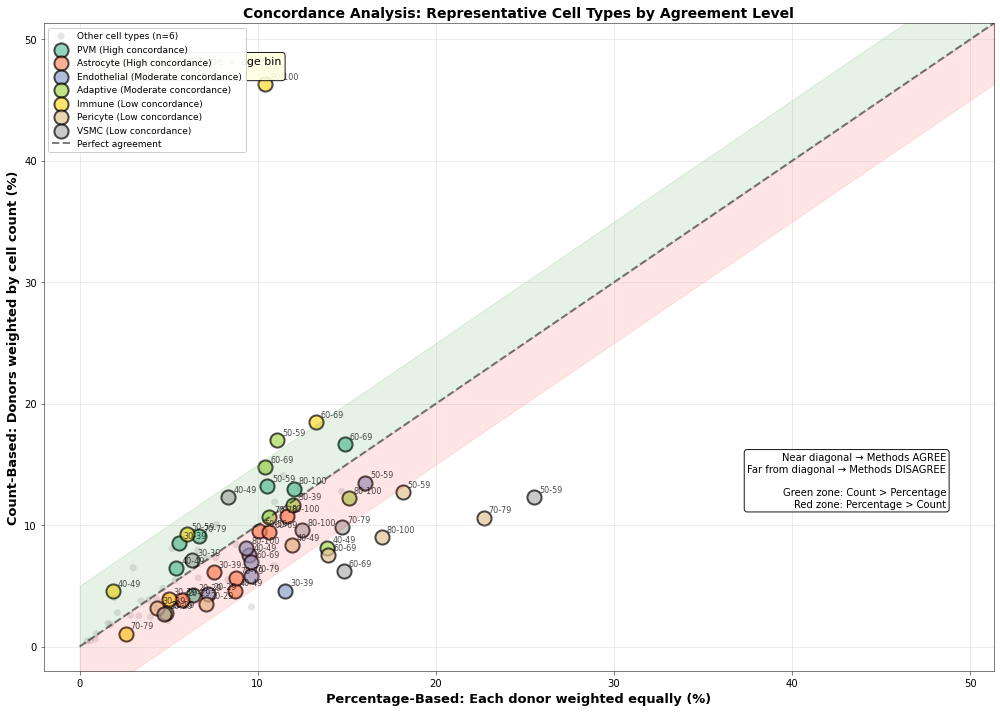


✓ Saved: /fs/scratch/PAS2598/senescence_analysis/figures/03_meta_analysis/03b_prevalence/prevalence_comparison_annotated.pdf

Key Takeaway:
  High concordance (7 types): PVM, Astrocyte, Microglia, Oligodendrocyte, OPC, Inhibitory, Excitatory
  Moderate concordance (3 types): Endothelial, Adaptive, VLMC
  Low concordance (3 types): Immune, Pericyte, VSMC


In [29]:
print("\n" + "="*80)
print("ANNOTATED CONCORDANCE PLOT")
print("="*80)

# Automatically select representative cell types from each concordance level
high_conc = df_cell_summary[df_cell_summary['Concordance'] == 'High']['Cell_Type'].tolist()
mod_conc = df_cell_summary[df_cell_summary['Concordance'] == 'Moderate']['Cell_Type'].tolist()
low_conc = df_cell_summary[df_cell_summary['Concordance'] == 'Low']['Cell_Type'].tolist()

# Select representatives: top 2 from each category
focus_types = []
focus_labels = {}

if len(high_conc) > 0:
    # Pick first 2 high concordance (or all if <2)
    selected_high = high_conc[:min(2, len(high_conc))]
    focus_types.extend(selected_high)
    for ct in selected_high:
        focus_labels[ct] = f'{ct} (High concordance)'

if len(mod_conc) > 0:
    # Pick first 2 moderate
    selected_mod = mod_conc[:min(2, len(mod_conc))]
    focus_types.extend(selected_mod)
    for ct in selected_mod:
        focus_labels[ct] = f'{ct} (Moderate concordance)'

if len(low_conc) > 0:
    # Pick all low concordance (usually few)
    focus_types.extend(low_conc)
    for ct in low_conc:
        focus_labels[ct] = f'{ct} (Low concordance)'

print(f"Focusing on {len(focus_types)} representative cell types:")
for ct in focus_types:
    print(f"  - {focus_labels[ct]}")

# Generate colors
from matplotlib import cm
n_focus = len(focus_types)
cmap = cm.get_cmap('Set2', n_focus)
colors_map = {ct: cmap(i) for i, ct in enumerate(focus_types)}

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Plot other cell types in background (gray)
other_types = [ct for ct in df_comparison['Cell_Type'].unique() if ct not in focus_types]
if len(other_types) > 0:
    other_data = df_comparison[df_comparison['Cell_Type'].isin(other_types)]
    ax.scatter(other_data['RE_mean'], other_data['CB_mean'], 
              s=50, alpha=0.2, c='gray', edgecolors='none', 
              label=f'Other cell types (n={len(other_types)})')

# Plot focused cell types with labels
for cell_type in focus_types:
    subset = df_comparison[df_comparison['Cell_Type'] == cell_type]
    
    sig_col_pct = 'RE_Significant' if 'RE_Significant' in df_comparison.columns else 'RE_Significant_pct'
    sig_col_cnt = 'CB_Significant' if 'CB_Significant' in df_comparison.columns else 'CB_Significant_cnt'
    
    both_sig = (subset[sig_col_pct]) & (subset[sig_col_cnt])
    
    # Plot all points for this cell type
    ax.scatter(subset['RE_mean'], subset['CB_mean'], 
              s=200, alpha=0.7, c=[colors_map[cell_type]], 
              edgecolors='black', linewidths=2, label=focus_labels[cell_type])
    
    # Add age bin labels for focused cell types
    for _, row in subset.iterrows():
        age_label = str(row['Study_Group']).replace('Age_', '').replace('_', '-')
        ax.annotate(age_label, 
                   xy=(row['RE_mean'], row['CB_mean']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=8, alpha=0.7)

# Identity line
max_val = max(df_comparison['RE_mean'].max(), df_comparison['CB_mean'].max()) + 5
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=2, label='Perfect agreement')

# Add interpretation zones
ax.fill_between([0, max_val], [0, max_val], [0+5, max_val+5], 
               alpha=0.1, color='green')
ax.fill_between([0, max_val], [0, max_val], [0-5, max_val-5], 
               alpha=0.1, color='red')

# Add explanatory text boxes
ax.text(0.05, 0.95, 
        'Each point = 1 cell type × age bin\nLabels show age group',
        transform=ax.transAxes,
        fontsize=11, ha='left', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black', linewidth=1))

# Add interpretation guide
interpretation_text = (
    'Near diagonal → Methods AGREE\n'
    'Far from diagonal → Methods DISAGREE\n\n'
    'Green zone: Count > Percentage\n'
    'Red zone: Percentage > Count'
)
ax.text(0.95, 0.25, interpretation_text,
        transform=ax.transAxes,
        fontsize=10, ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=1))

# Formatting
ax.set_xlabel('Percentage-Based: Each donor weighted equally (%)', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('Count-Based: Donors weighted by cell count (%)', 
             fontsize=13, fontweight='bold')
ax.set_title('Concordance Analysis: Representative Cell Types by Agreement Level', 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=9, framealpha=0.95, ncol=1)
ax.set_xlim(-2, max_val)
ax.set_ylim(-2, max_val)

plt.tight_layout()
plt.savefig(FIGURES_DIR_03B / 'prevalence_comparison_annotated.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {FIGURES_DIR_03B / 'prevalence_comparison_annotated.pdf'}")
print("\nKey Takeaway:")
for level in ['High', 'Moderate', 'Low']:
    types = df_cell_summary[df_cell_summary['Concordance'] == level]['Cell_Type'].tolist()
    if len(types) > 0:
        print(f"  {level} concordance ({len(types)} types): {', '.join(types)}")
print("="*80)